In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
from utils.parse_coscheduling_runs import CoSchedulingRunsParser
from utils.parse_coscheduling_runs_parallel import CoSchedulingRunsParserParallel

In [2]:
parser = CoSchedulingRunsParser()
data_isolated = parser.parse_isolated("../sample_data/experiments_coscheduling_isolated/20260527_083005/data", progress=True)
print("Finished parsing isolated")
data_coscheduled = parser.parse_coscheduled("../sample_data/experiments_coscheduling_app_coscheduled/20260527_082956/data", progress=True)
print("Finished parsing app coscheduled")
data_inhib_coscheduled = parser.parse_inhibitor_coscheduled("../sample_data/experiments_coscheduling_inhib_coscheduled/20260529_102306/data", progress=True)


# parser = CoSchedulingRunsParserParallel()
# data_isolated = parser.parse_isolated_parallel("../sample_data/experiments_coscheduling_isolated/20260527_083005/data")
# data_coscheduled = parser.parse_coscheduled_parallel("../sample_data/experiments_coscheduling_app_coscheduled/20260527_082956/data")
# data_inhib_coscheduled = parser.parse_inhibitor_coscheduled_parallel("../sample_data/experiments_coscheduling_inhib_coscheduled/20260529_102306/data")

Phase 1: Collecting files: 64it [00:00, 8753.23it/s]
Phase 2: Parsing files:   0%|          | 0/64 [00:00<?, ?it/s]

Phase 2: Parsing files: 100%|██████████| 64/64 [00:19<00:00,  3.31it/s]


Finished parsing isolated


Phase 1: Collecting files: 304it [00:00, 10599.42it/s]
Phase 2: Parsing files: 100%|██████████| 304/304 [03:27<00:00,  1.46it/s]


Finished parsing app coscheduled


Phase 1: Collecting files: 5760it [00:00, 11673.48it/s]
Phase 2: Parsing files: 100%|██████████| 5760/5760 [38:45<00:00,  2.48it/s]  


In [3]:
# Aggregate data_isolated by App and Num Nodes
# Group by App and Num Nodes, then calculate mean, median, std for each metric across Run Iterations
data_isolated_agg = data_isolated.groupby(['App', 'Num Nodes']).agg({
    'App Time Average': ['mean', 'median', 'std'],
    'MPI Time Average': ['mean', 'median', 'std'],
    'Total Messages Sent': ['mean', 'median', 'std']
}).reset_index()

# Flatten column names
data_isolated_agg.columns = ['App', 'Num Nodes', 
                             'App Time Average Mean', 'App Time Average Median', 'App Time Average Std',
                             'MPI Time Average Mean', 'MPI Time Average Median', 'MPI Time Average Std',
                             'Total Messages Sent Mean', 'Total Messages Sent Median', 'Total Messages Sent Std']

data_isolated_agg

,App,Num Nodes,App Time Average Mean,App Time Average Median,App Time Average Std,MPI Time Average Mean,MPI Time Average Median,MPI Time Average Std,Total Messages Sent Mean,Total Messages Sent Median,Total Messages Sent Std
0,amg,8,342.500000,343.000000,1.000000,12.778086,13.185714,0.995017,106441449.0,106441449.0,0.0
1,beatnik,1,370.147321,372.437500,6.710143,84.769196,84.929464,1.452374,375894.0,375894.0,0.0
2,beatnik,8,397.734375,396.977679,4.860808,99.906362,98.491295,3.282818,19996182.0,19996182.0,0.0
3,fiesta,1,298.683036,298.687500,0.166481,37.266161,37.482589,1.644729,67200.0,67200.0,0.0
4,fiesta,8,359.091518,357.470982,3.688871,65.675446,64.003013,5.682057,645120.0,645120.0,0.0
5,kripke,8,354.500000,354.500000,0.577350,17.006585,16.945201,0.547324,302720.0,302720.0,0.0
6,laghos,8,331.237723,332.007812,15.994063,54.944978,55.503237,15.080986,801311390.0,801311390.0,0.0
7,lammps,1,265.750000,266.500000,2.872281,3.272009,3.249018,0.053727,44688.0,44688.0,0.0
8,lammps,8,354.750000,356.000000,3.304038,17.381222,17.574632,2.804269,457408.0,457408.0,0.0
9,minife,1,383.750000,384.000000,1.258306,9.700491,9.945357,0.684815,637048.0,637048.0,0.0


In [4]:
# Aggregate data_coscheduled by App A, App B, and Num Nodes
# Group by App A, App B, and Num Nodes, then calculate mean, median, std for each metric across Run Iterations
data_coscheduled_agg = data_coscheduled.groupby(['App A', 'App B', 'Num Nodes']).agg({
    'App A Time Average': ['mean', 'median', 'std'],
    'App B Time Average': ['mean', 'median', 'std'],
    'App A MPI Time Average': ['mean', 'median', 'std'],
    'App B MPI Time Average': ['mean', 'median', 'std'],
    'App A Total Messages Sent': ['mean', 'median', 'std'],
    'App B Total Messages Sent': ['mean', 'median', 'std']
}).reset_index()

# Flatten column names
data_coscheduled_agg.columns = ['App A', 'App B', 'Num Nodes',
                                'App A Time Average Mean', 'App A Time Average Median', 'App A Time Average Std',
                                'App B Time Average Mean', 'App B Time Average Median', 'App B Time Average Std',
                                'App A MPI Time Average Mean', 'App A MPI Time Average Median', 'App A MPI Time Average Std',
                                'App B MPI Time Average Mean', 'App B MPI Time Average Median', 'App B MPI Time Average Std',
                                'App A Total Messages Sent Mean', 'App A Total Messages Sent Median', 'App A Total Messages Sent Std',
                                'App B Total Messages Sent Mean', 'App B Total Messages Sent Median', 'App B Total Messages Sent Std']

data_coscheduled_agg

,App A,App B,Num Nodes,App A Time Average Mean,App A Time Average Median,App A Time Average Std,App B Time Average Mean,App B Time Average Median,App B Time Average Std,App A MPI Time Average Mean,...,App A MPI Time Average Std,App B MPI Time Average Mean,App B MPI Time Average Median,App B MPI Time Average Std,App A Total Messages Sent Mean,App A Total Messages Sent Median,App A Total Messages Sent Std,App B Total Messages Sent Mean,App B Total Messages Sent Median,App B Total Messages Sent Std
0,amg,amg,8,345.000000,345.500000,2.160247,341.250000,341.0,1.258306,16.571261,...,2.372652,12.247377,11.551150,1.736756,106441449.0,106441449.0,0.0,106441449.0,106441449.0,0.0
1,amg,kripke,8,343.000000,343.000000,1.825742,354.750000,355.0,0.500000,14.017204,...,2.098622,17.599777,17.623214,0.429961,106441449.0,106441449.0,0.0,302720.0,302720.0,0.0
2,amg,laghos,8,343.750000,343.500000,0.957427,359.750000,359.5,9.069179,14.706105,...,1.466030,85.912444,85.982031,9.422738,106441449.0,106441449.0,0.0,801311390.0,801311390.0,0.0
3,amg,quicksilver,8,341.750000,341.500000,0.957427,296.376674,296.0,5.526456,12.807433,...,1.062204,135.486373,135.059063,5.406431,106441449.0,106441449.0,0.0,762710.0,762710.0,0.0
4,beatnik,amg,8,407.433594,407.920759,2.641310,345.750000,346.0,1.500000,114.305246,...,2.155174,19.768080,19.922321,1.580418,19996182.0,19996182.0,0.0,106441449.0,106441449.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,tricount,minivite,1,280.750000,280.500000,0.957427,440.250000,439.0,6.500000,50.109821,...,0.954537,27.737366,26.140804,5.058123,243320.0,243320.0,0.0,747720.0,747720.0,0.0
72,tricount,minivite,8,399.000000,397.000000,5.416026,384.750000,383.5,4.500000,225.238839,...,5.390014,66.457087,65.082031,4.971642,7120960.0,7120960.0,0.0,24089720.0,24089720.0,0.0
73,tricount,quicksilver,8,385.250000,385.500000,3.304038,295.750000,296.5,5.057997,212.002232,...,2.984644,134.480954,135.265100,4.878908,7120960.0,7120960.0,0.0,762710.0,762710.0,0.0
74,tricount,tricount,1,285.500000,285.500000,5.802298,281.500000,281.5,1.290994,50.300000,...,0.855260,50.667411,50.795536,0.648622,243320.0,243320.0,0.0,243320.0,243320.0,0.0


In [5]:
# Aggregate data_inhib coscheduled by App and Num Nodes
# Group by App, Num Nodes, Inhib Message Size, Inhib Wait Time (us), Inhib Comm Sparsity, Inhib Comm Mode then calculate mean, median, std for each metric across Run Iterations
data_inhib_coscheduled_agg = data_inhib_coscheduled.groupby(['App', 'Num Nodes', 'Inhib Message Size', 'Inhib Wait Time (us)', 'Inhib Comm Sparsity', 'Inhib Comm Mode']).agg({
    'App Time Average': ['mean', 'median', 'std'],
    'MPI Time Average': ['mean', 'median', 'std'],
    'Total Messages Sent': ['mean', 'median', 'std']
}).reset_index()

# Flatten column names
data_inhib_coscheduled_agg.columns = ['App', 'Num Nodes', 'Inhib Message Size', 'Inhib Wait Time (us)', 'Inhib Comm Sparsity', 'Inhib Comm Mode',
                             'App Time Average Mean', 'App Time Average Median', 'App Time Average Std',
                             'MPI Time Average Mean', 'MPI Time Average Median', 'MPI Time Average Std',
                             'Total Messages Sent Mean', 'Total Messages Sent Median', 'Total Messages Sent Std']

data_inhib_coscheduled_agg

,App,Num Nodes,Inhib Message Size,Inhib Wait Time (us),Inhib Comm Sparsity,Inhib Comm Mode,App Time Average Mean,App Time Average Median,App Time Average Std,MPI Time Average Mean,MPI Time Average Median,MPI Time Average Std,Total Messages Sent Mean,Total Messages Sent Median,Total Messages Sent Std
0,beatnik,8,2000,0,0.1,d,425.018415,428.850446,9.421738,126.700893,129.215402,5.252053,19996182.0,19996182.0,0.0
1,beatnik,8,2000,0,0.3,d,411.276228,410.992188,5.607571,117.027344,116.558036,4.527603,19996182.0,19996182.0,0.0
2,beatnik,8,2000,0,0.5,d,408.000000,408.500000,4.242641,113.647377,113.832589,3.789133,19996182.0,19996182.0,0.0
3,beatnik,8,2000,0,0.7,d,404.174665,404.367188,3.301730,109.258538,109.002232,1.025031,19996182.0,19996182.0,0.0
4,beatnik,8,2000,0,1.0,d,406.275670,407.000000,3.899116,109.532589,108.565402,3.603378,19996182.0,19996182.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,tricount,8,4000000,1000000,0.1,d,507.000000,491.500000,50.523922,332.457589,317.334821,51.135075,7120960.0,7120960.0,0.0
1436,tricount,8,4000000,1000000,0.3,d,565.750000,585.500000,50.241915,392.374442,412.047991,49.962897,7120960.0,7120960.0,0.0
1437,tricount,8,4000000,1000000,0.5,d,616.750000,611.000000,43.873872,443.263393,437.483259,43.873631,7120960.0,7120960.0,0.0
1438,tricount,8,4000000,1000000,0.7,d,584.000000,602.000000,59.520305,410.602679,428.400670,59.863348,7120960.0,7120960.0,0.0


In [6]:
# Write processed dataframes to csv files
data_isolated.to_csv("../processed_data/data_isolated.csv")
data_isolated_agg.to_csv("../processed_data/data_isolated_agg.csv")
data_coscheduled.to_csv("../processed_data/data_coscheduled.csv")
data_coscheduled_agg.to_csv("../processed_data/data_coscheduled_agg.csv")
data_inhib_coscheduled.to_csv("../processed_data/data_inhib_coscheduled.csv")
data_inhib_coscheduled_agg.to_csv("../processed_data/data_inhib_coscheduled_agg.csv")

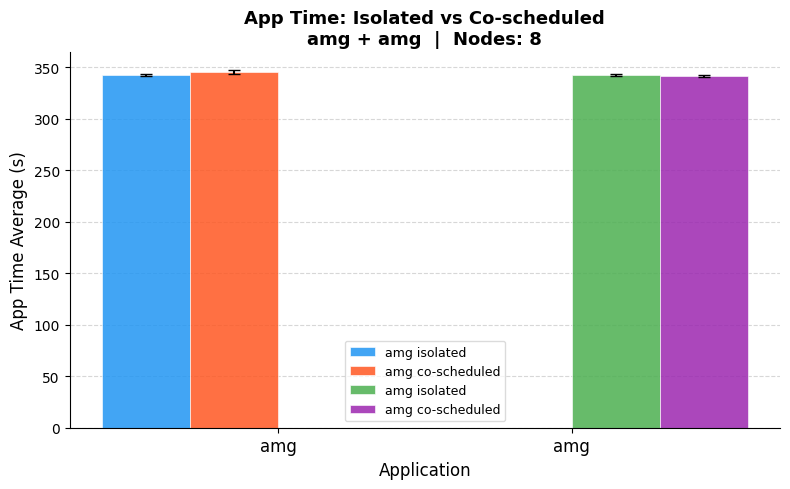

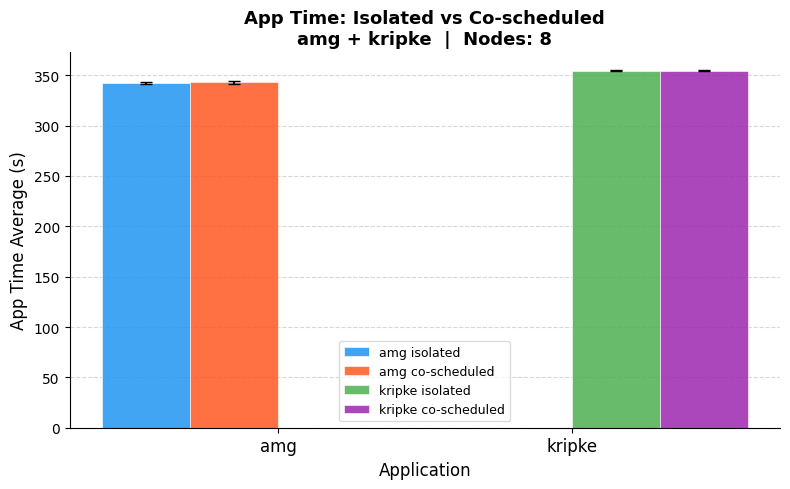

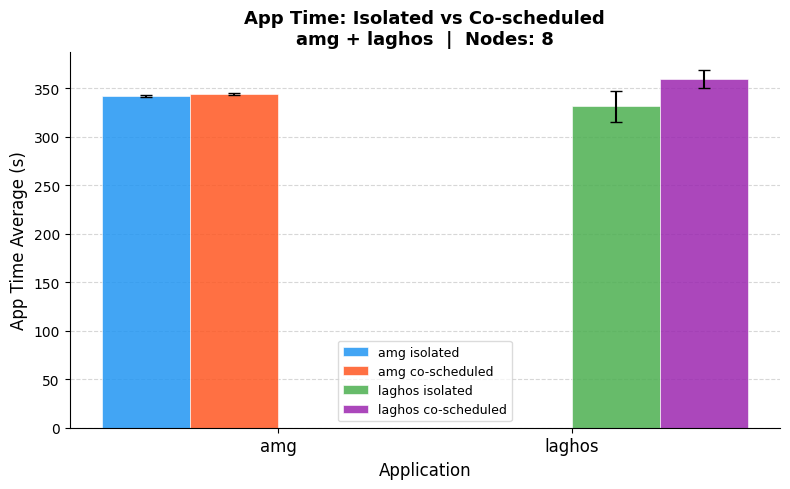

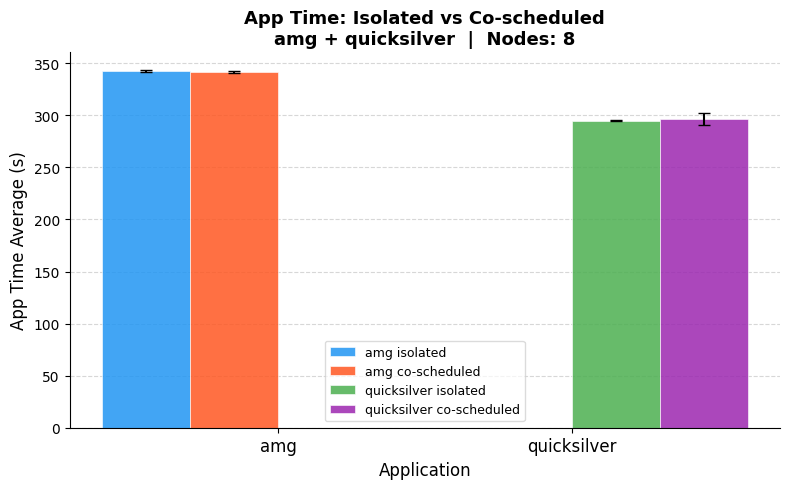

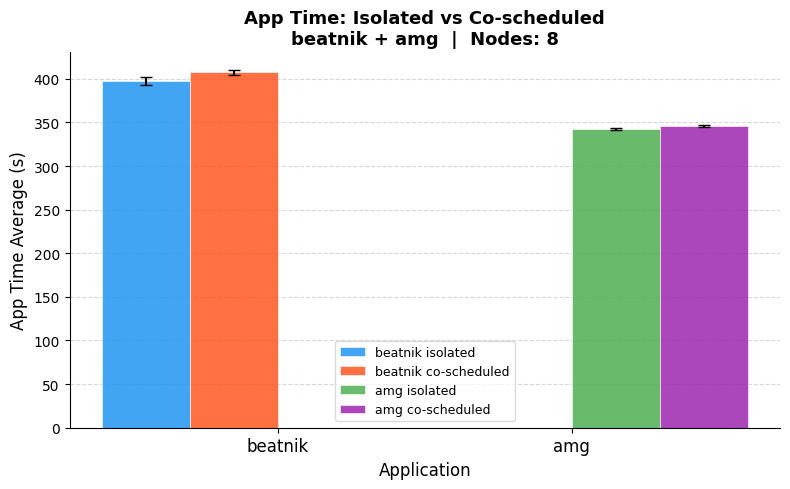

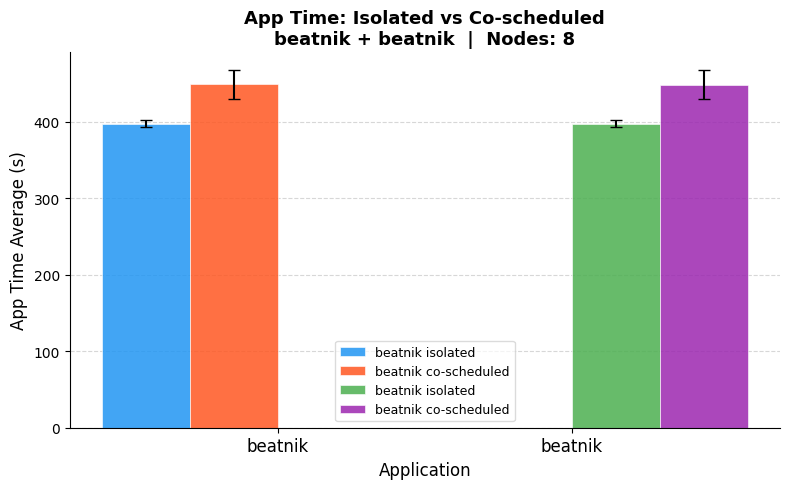

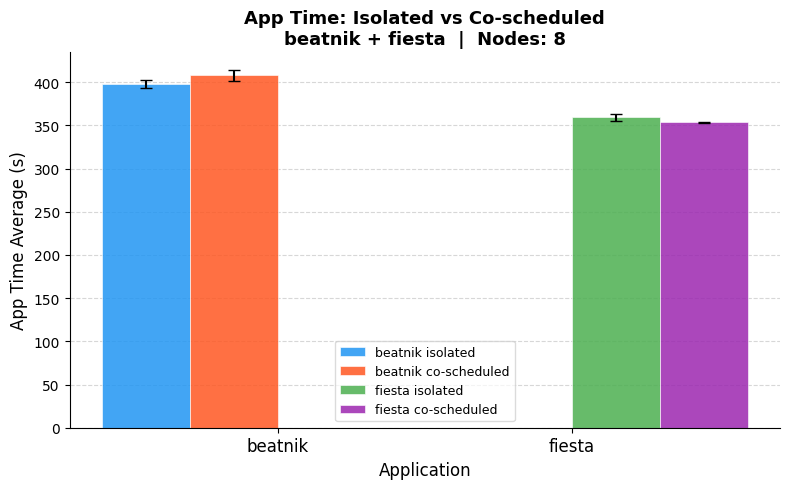

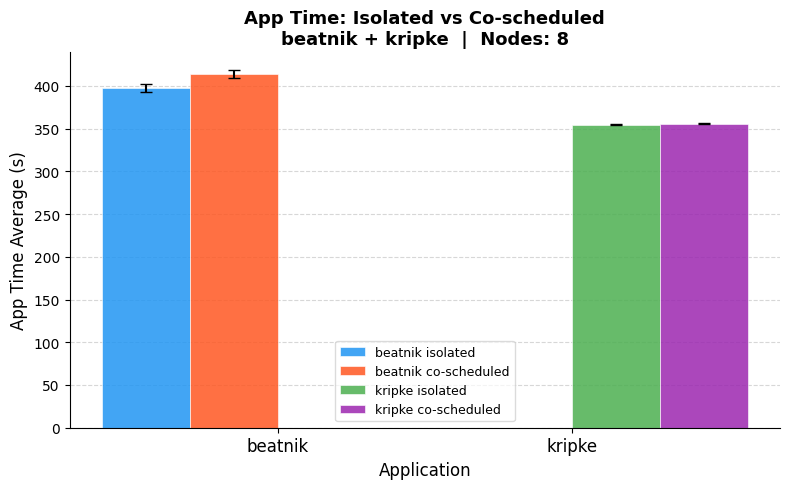

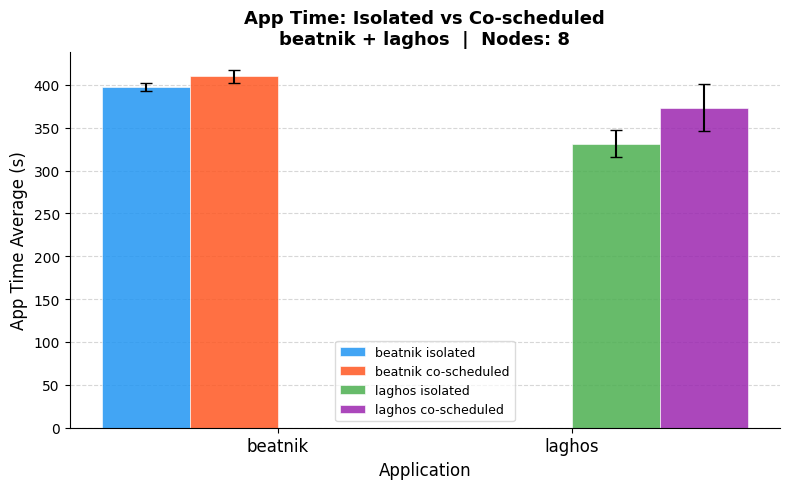

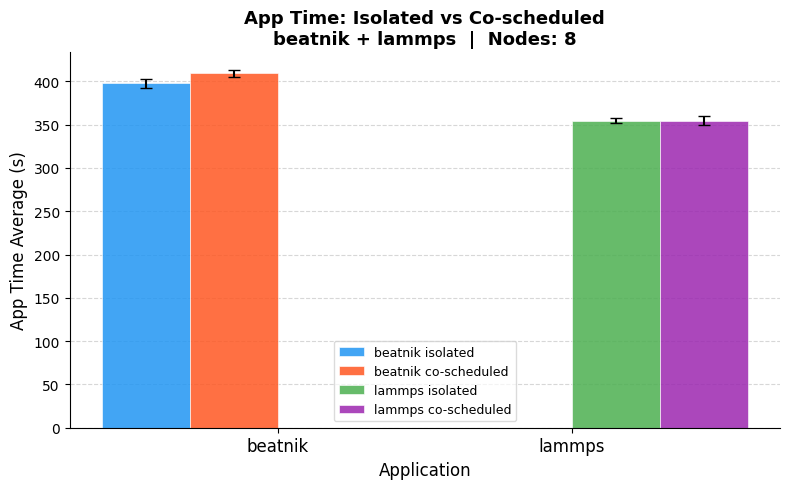

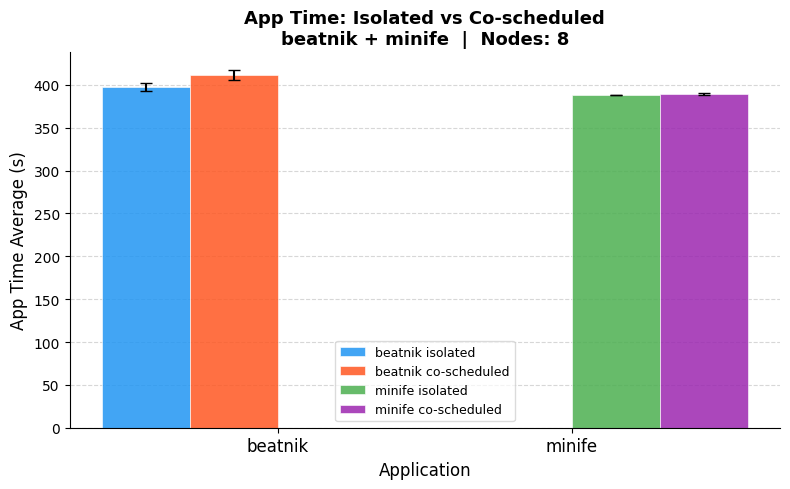

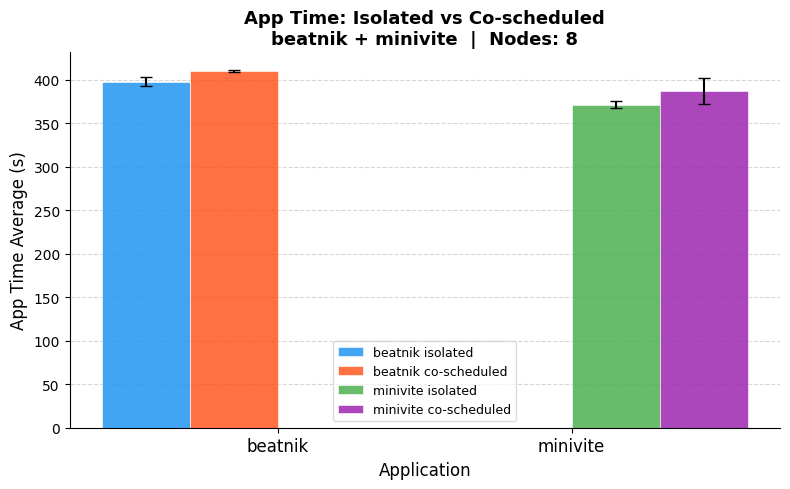

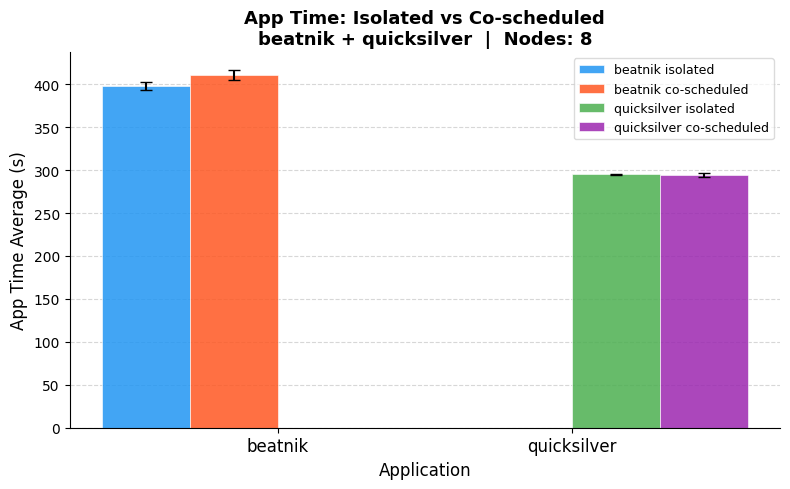

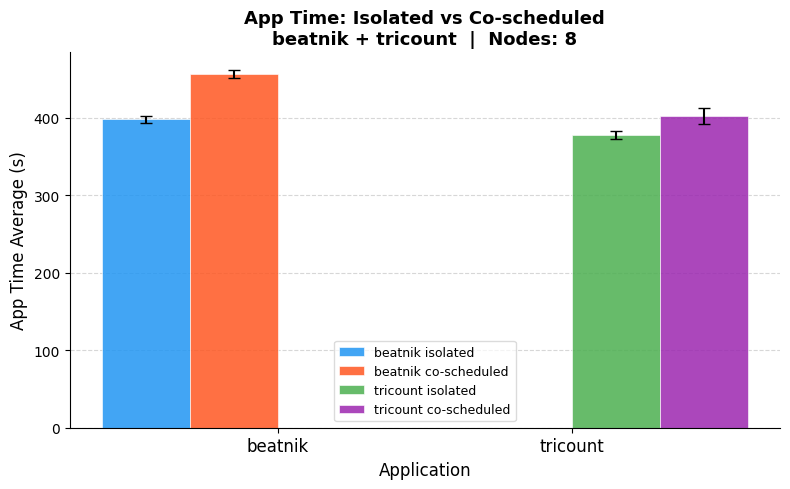

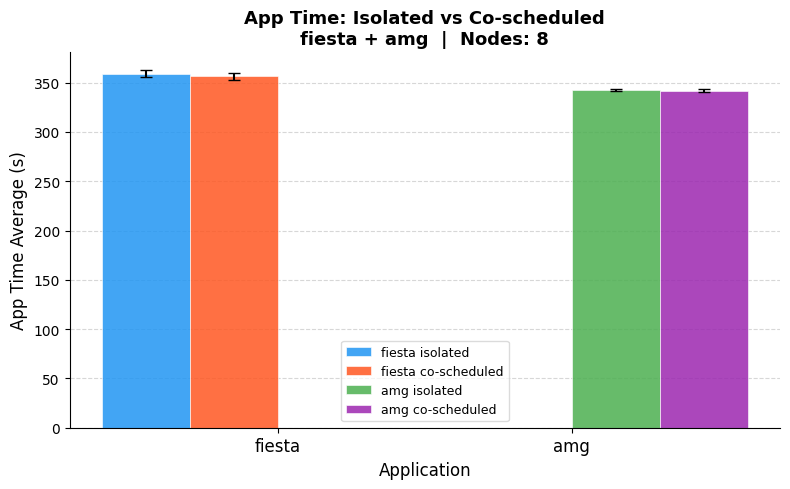

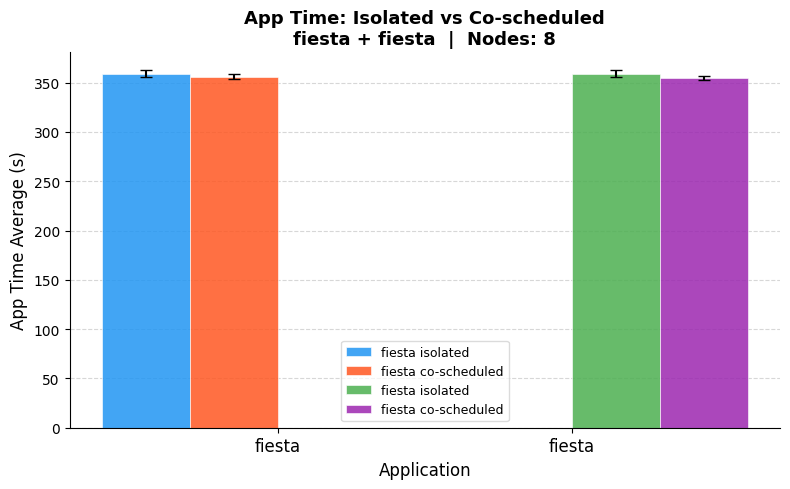

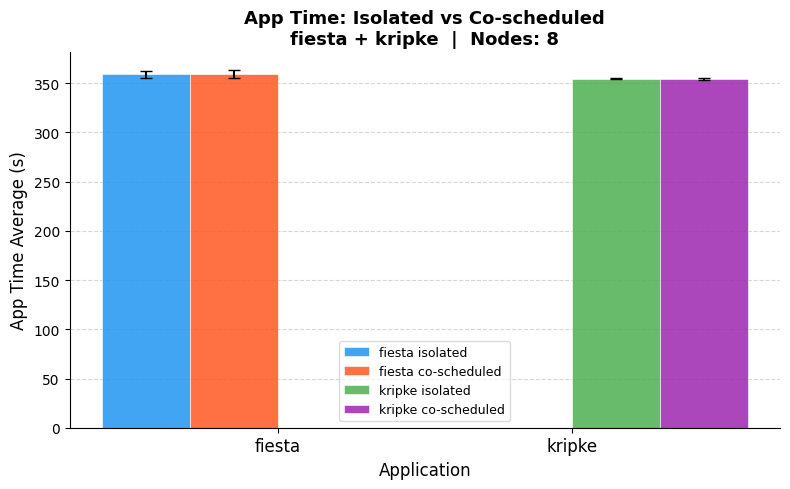

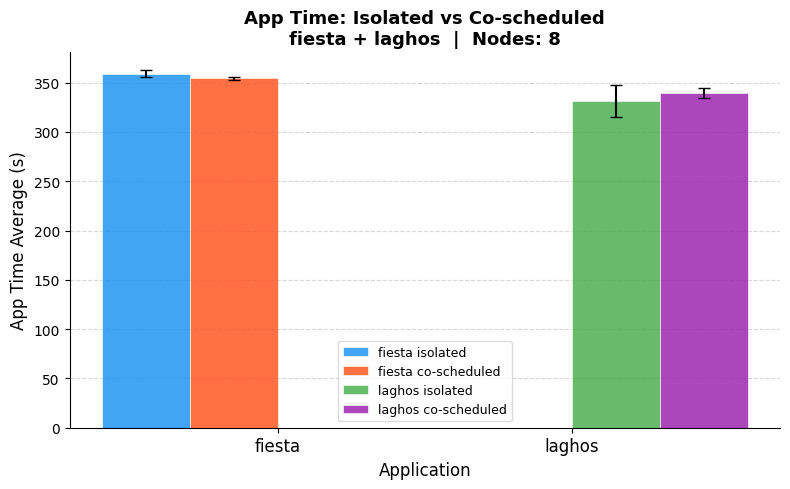

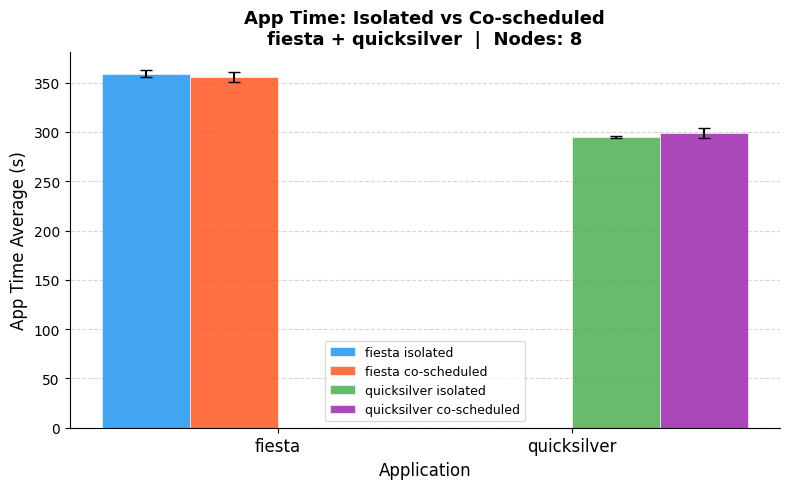

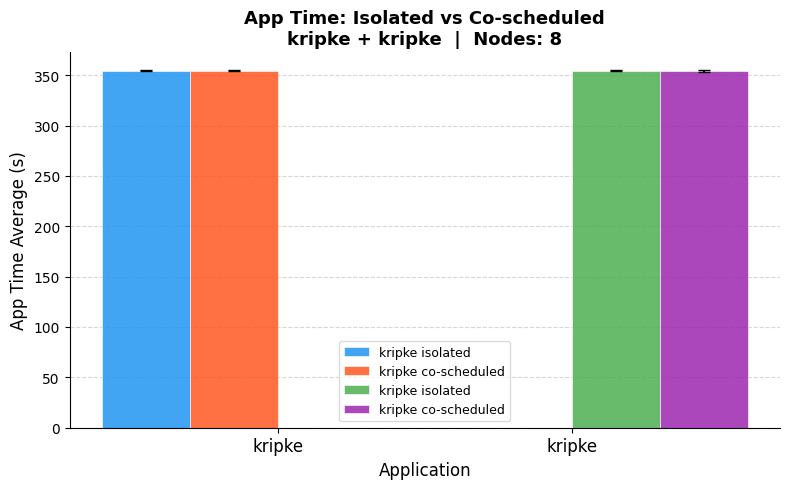

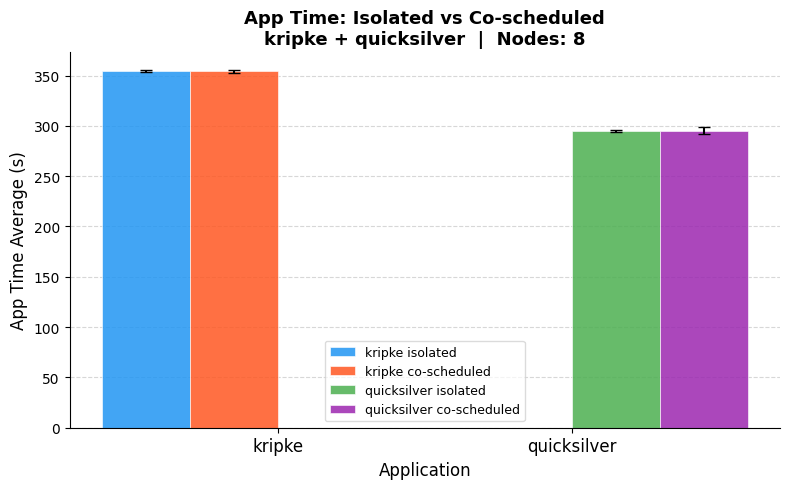

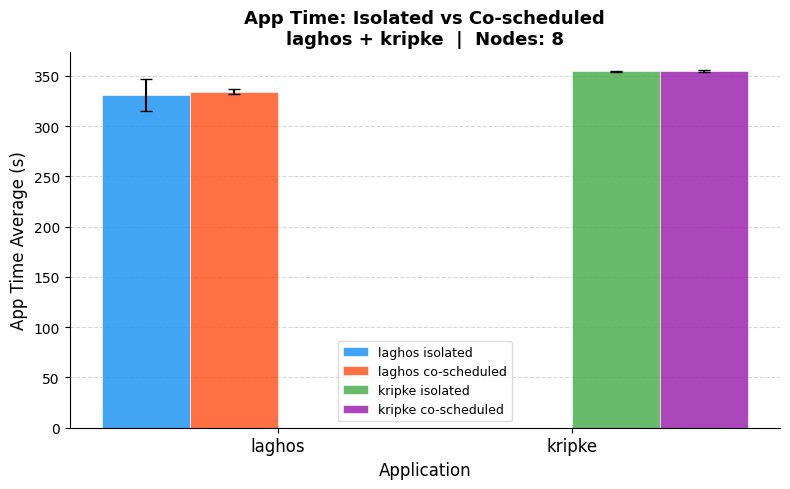

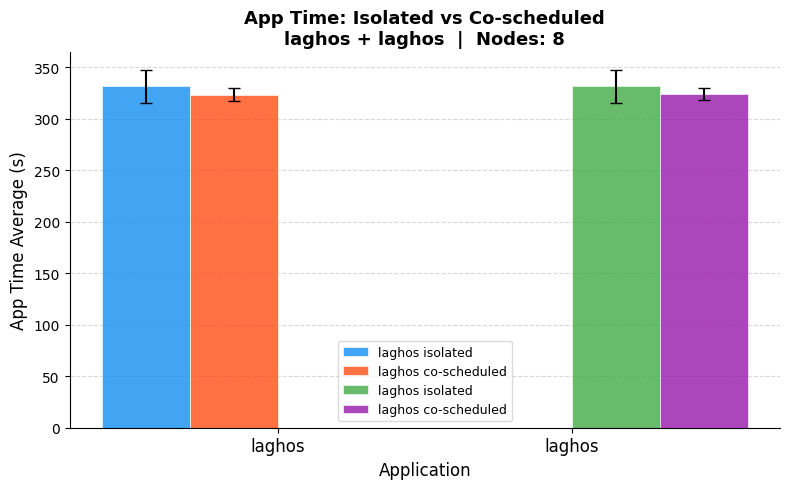

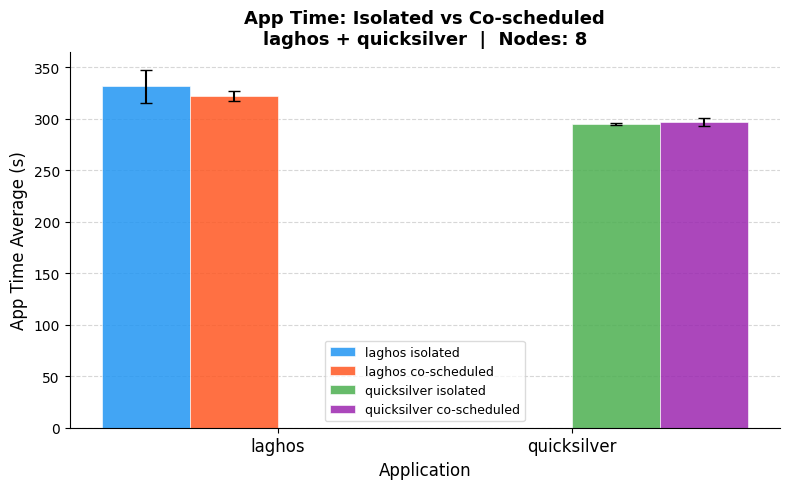

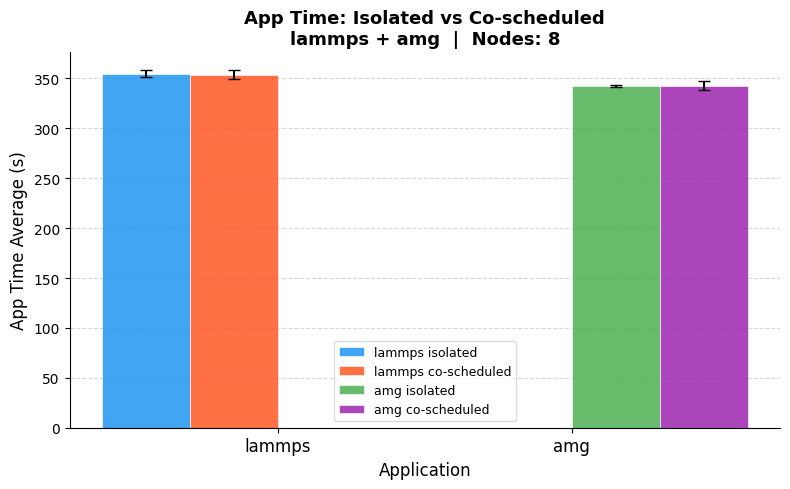

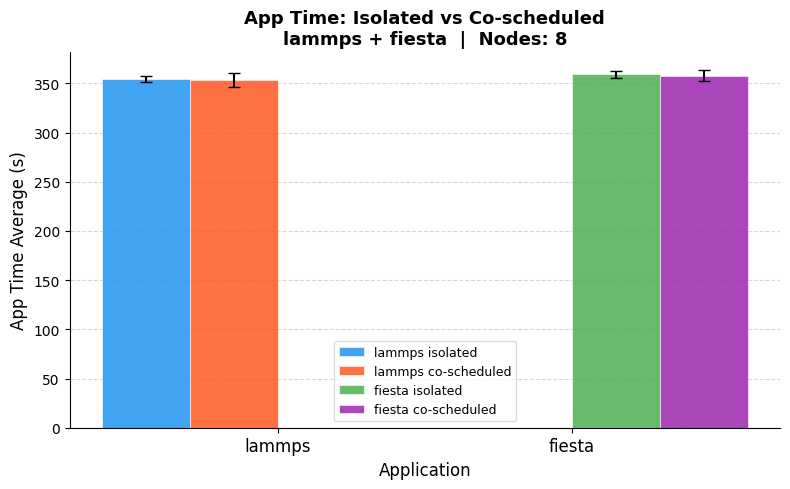

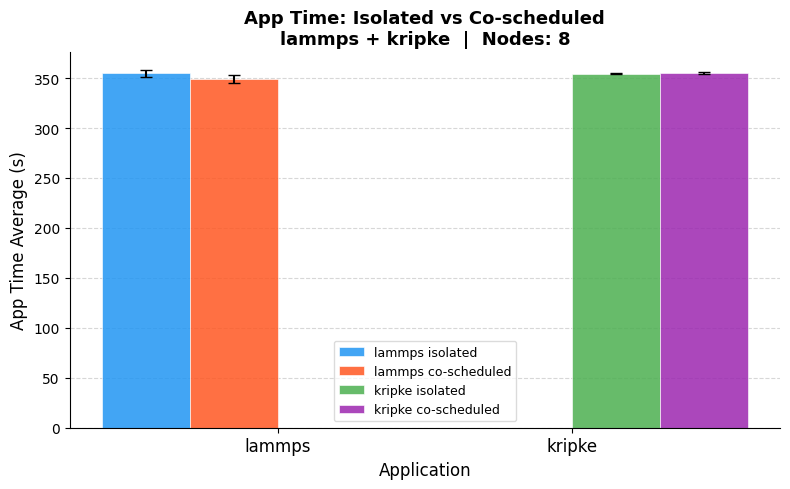

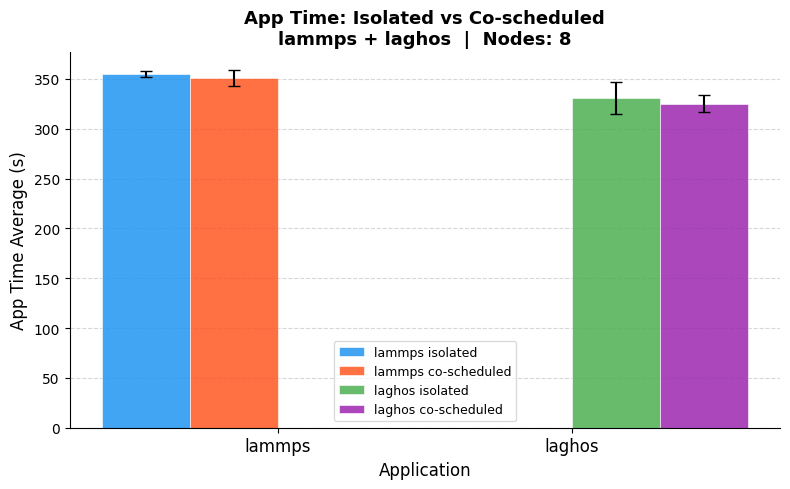

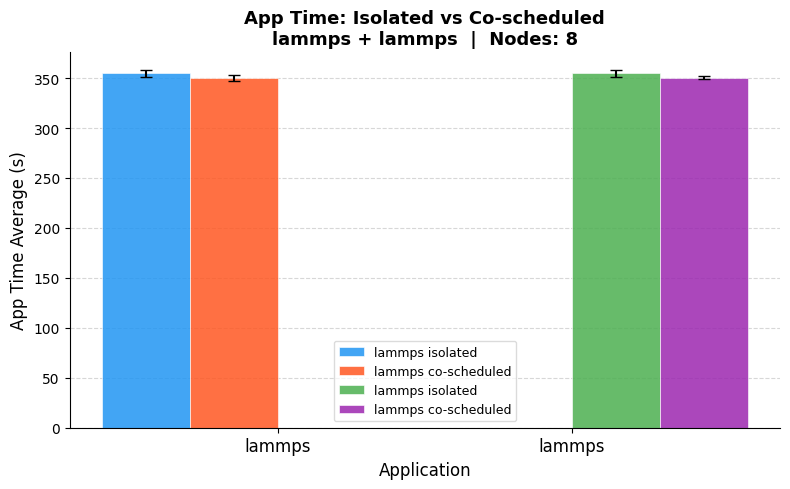

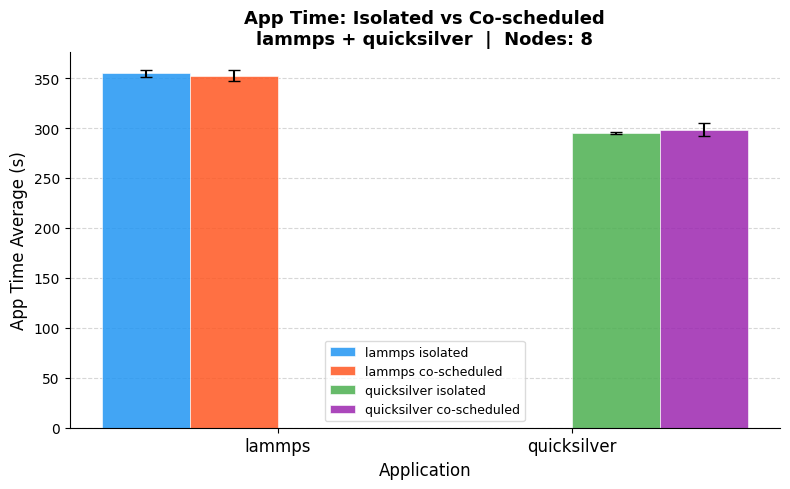

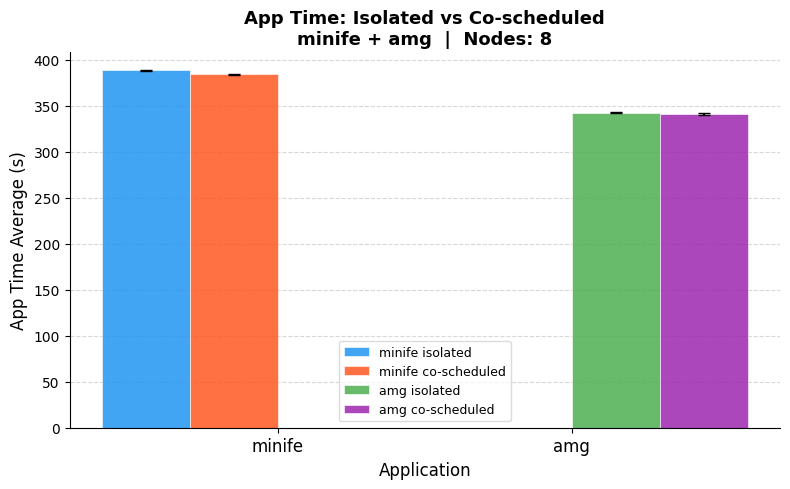

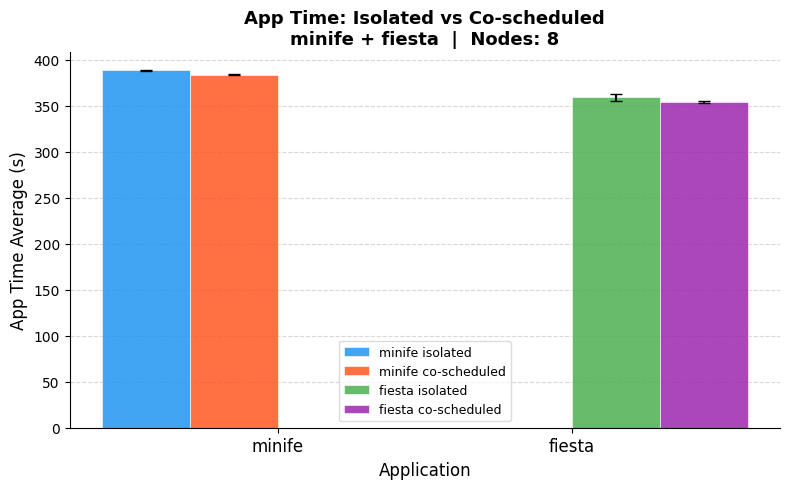

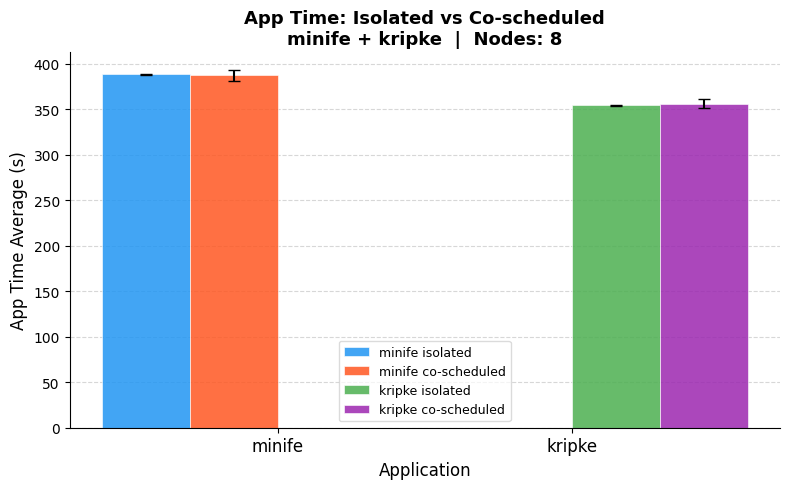

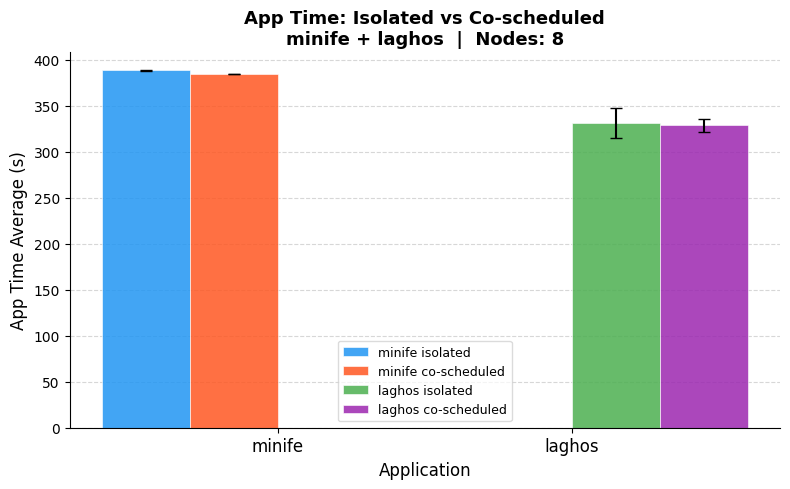

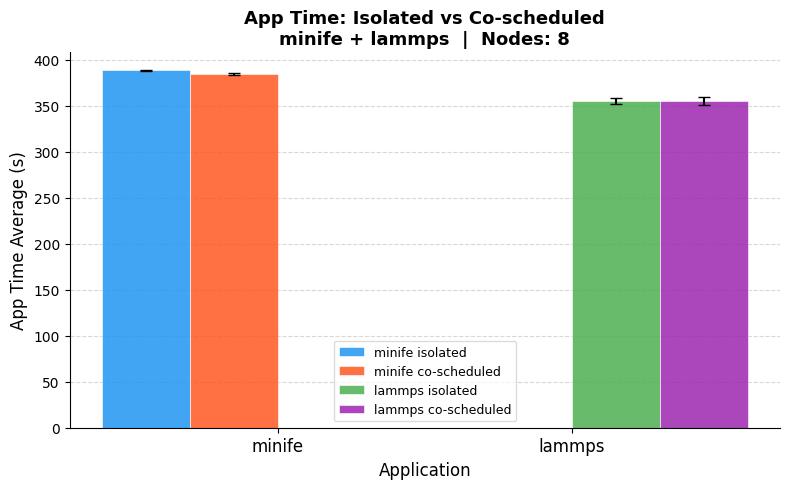

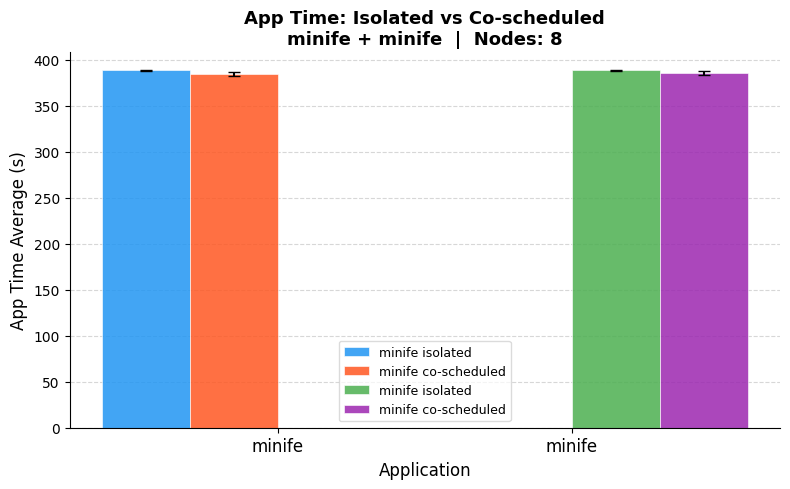

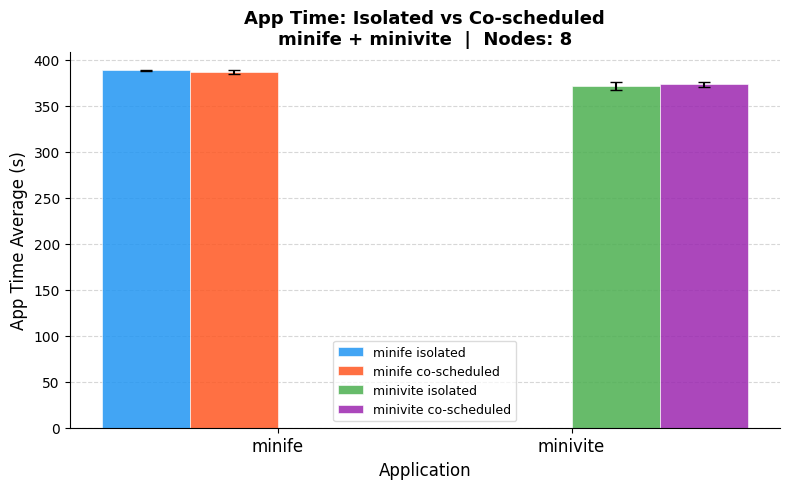

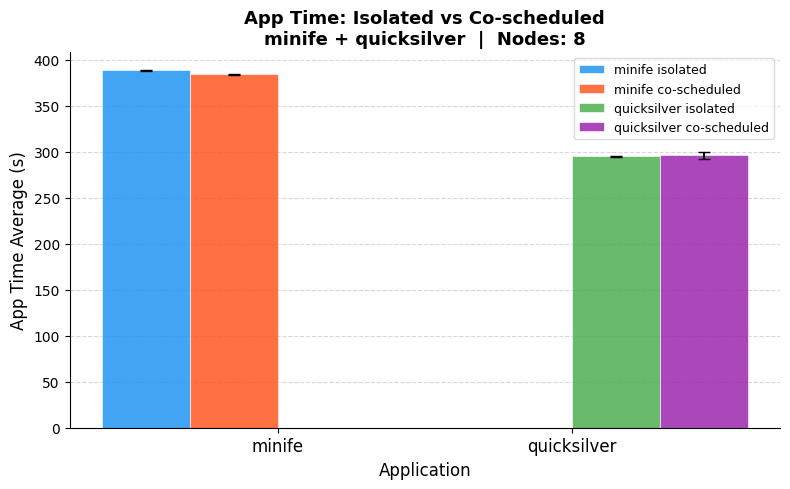

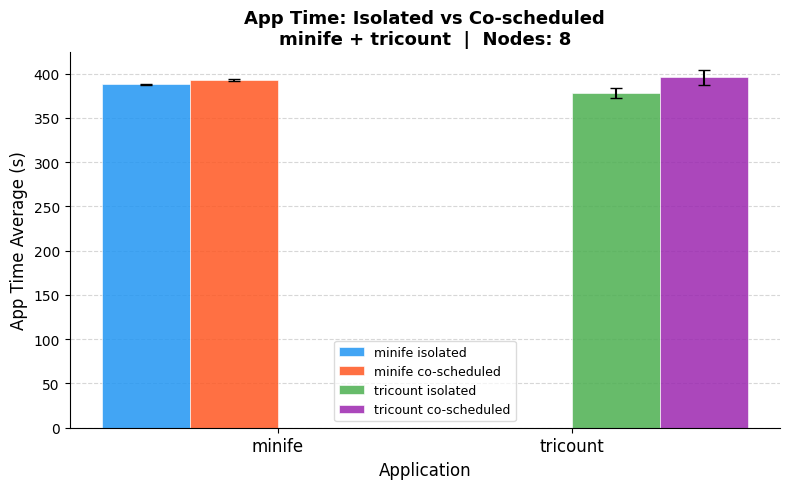

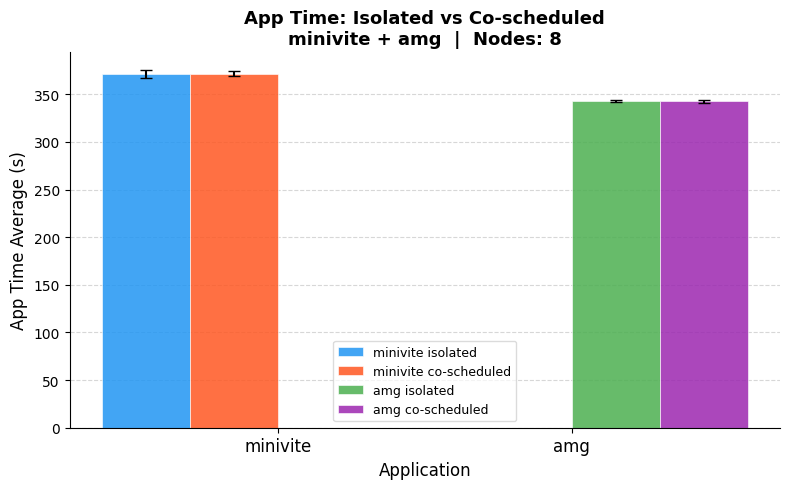

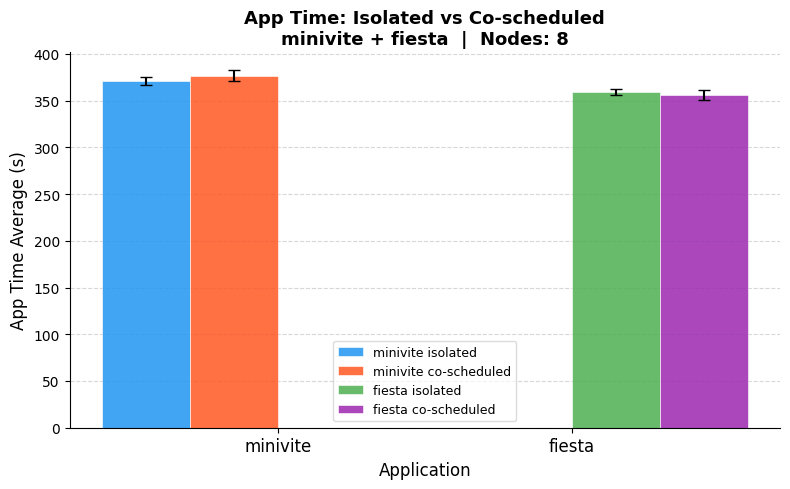

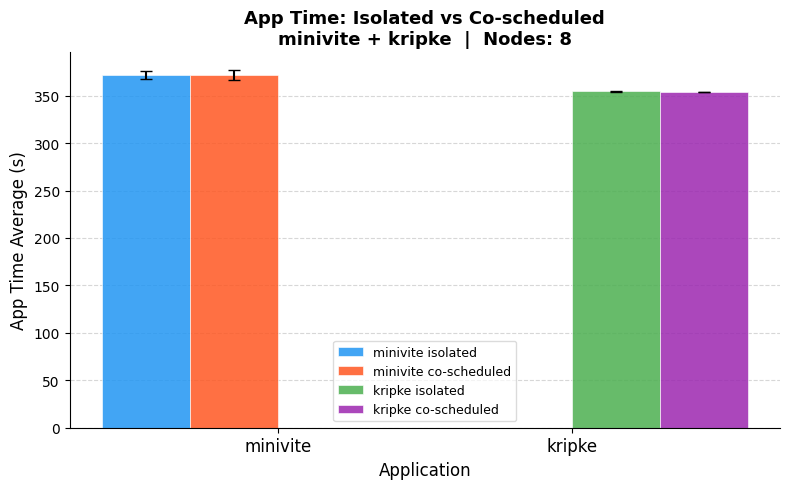

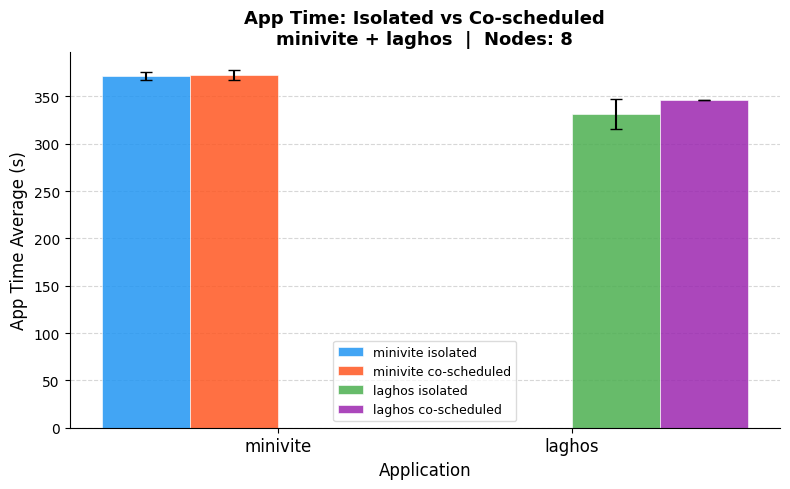

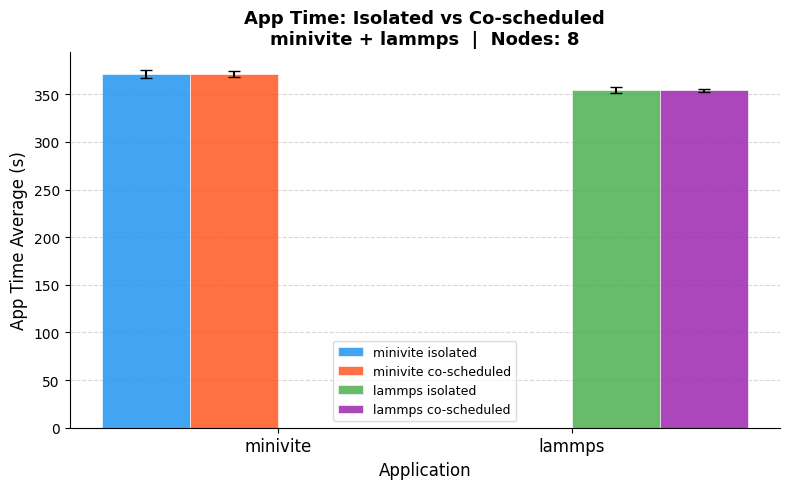

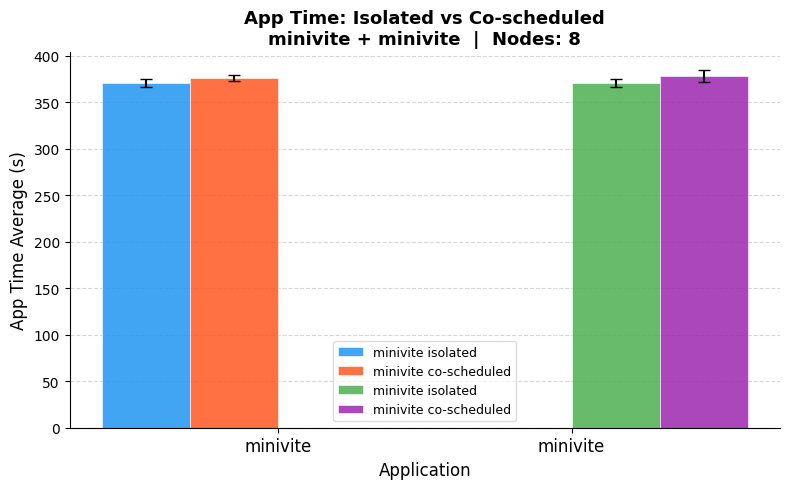

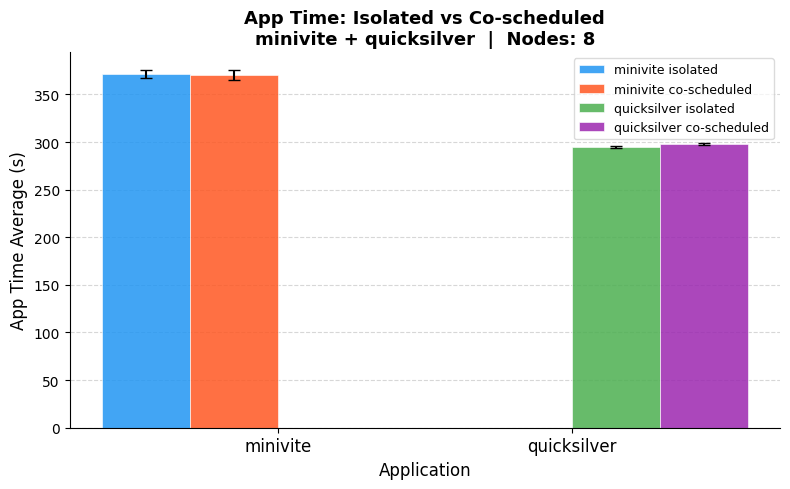

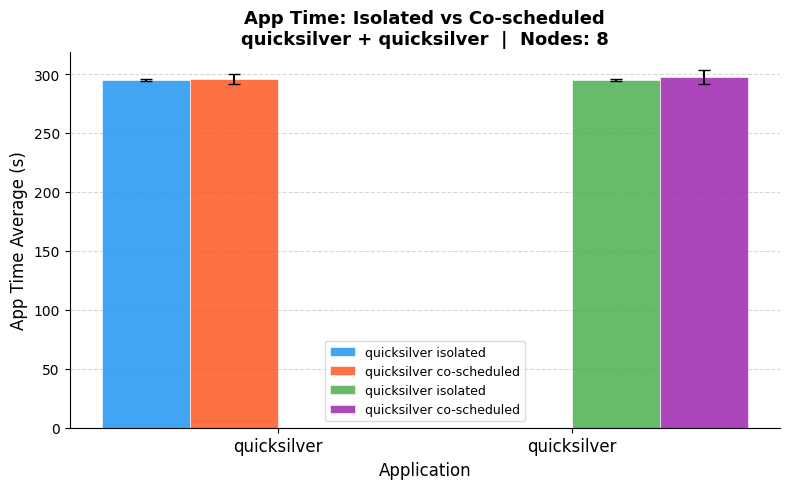

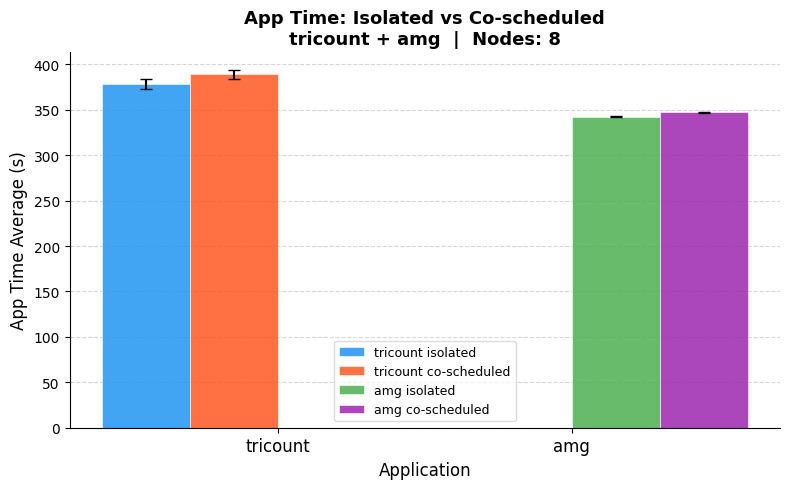

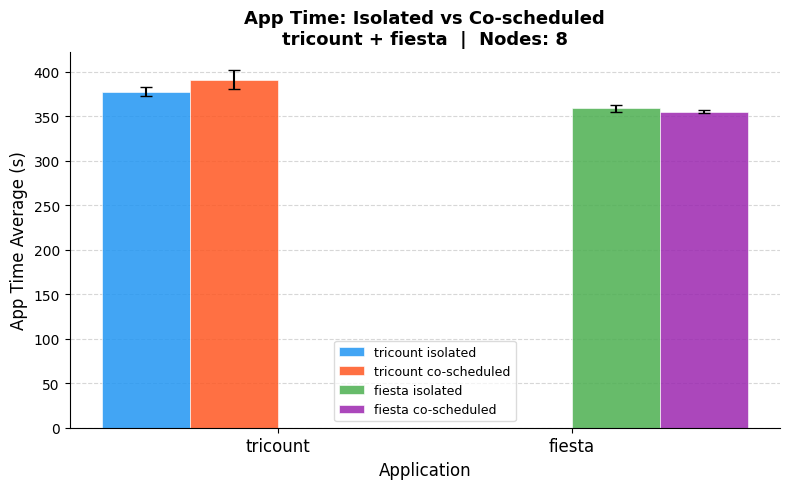

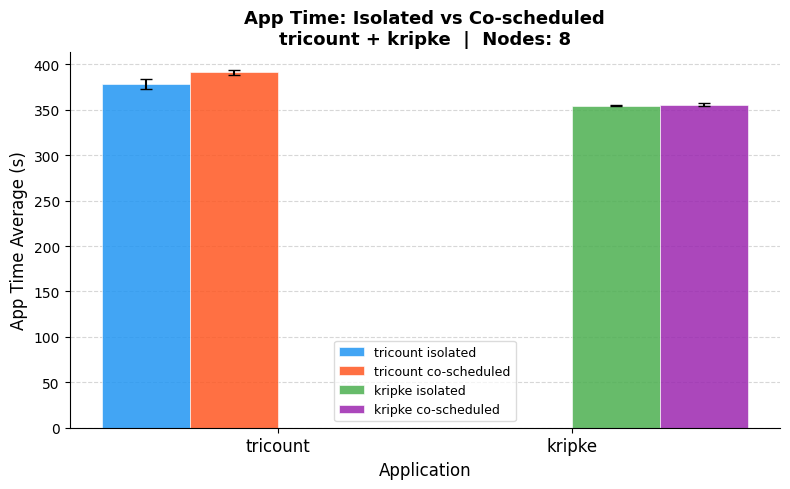

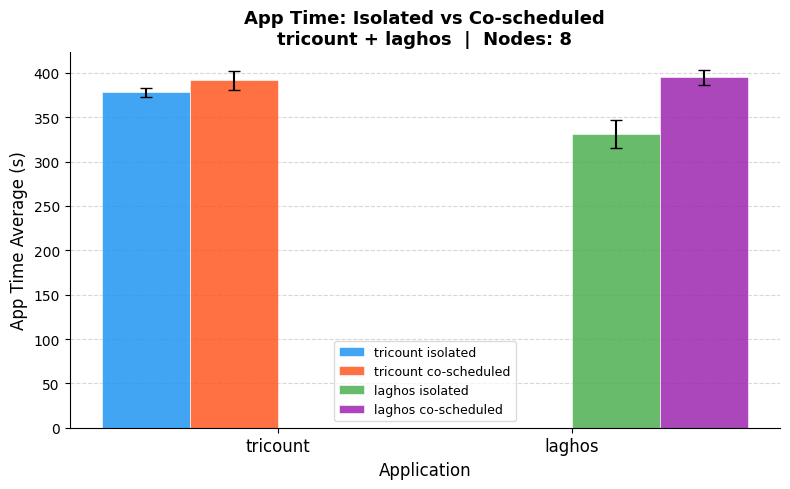

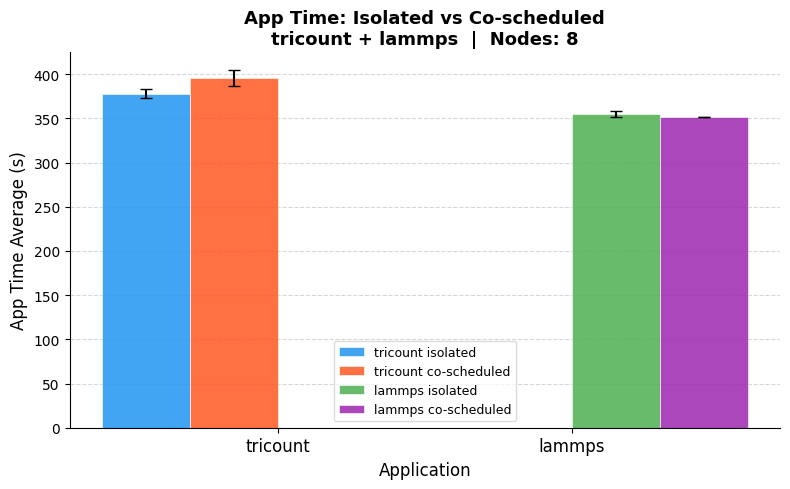

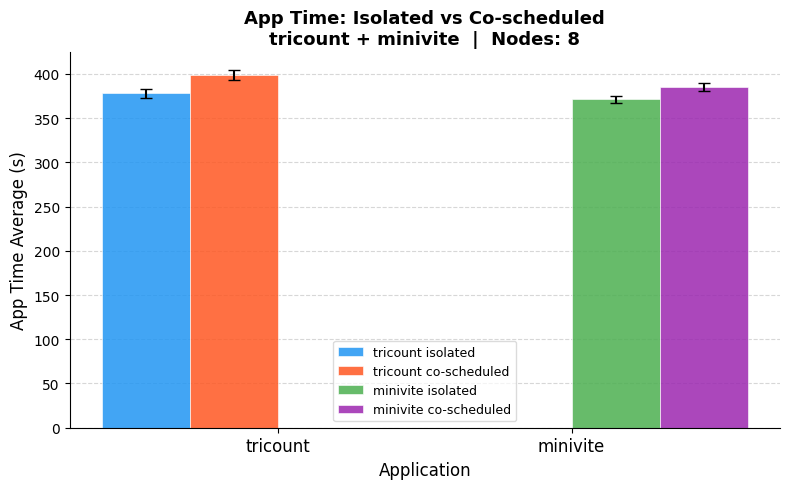

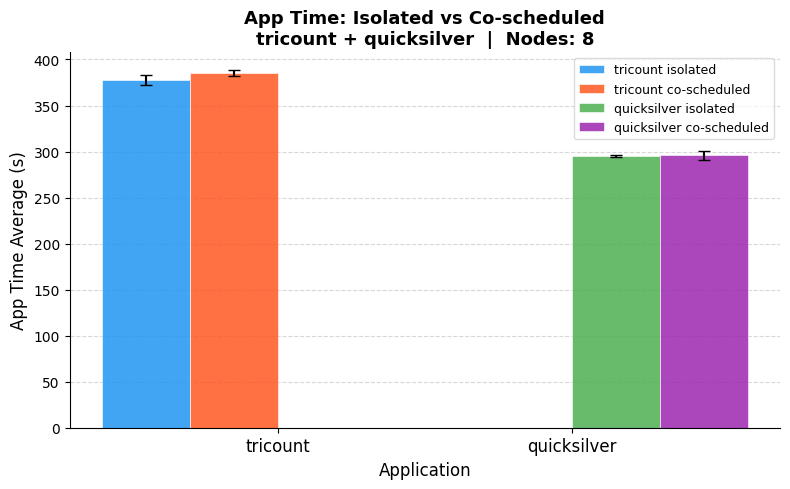

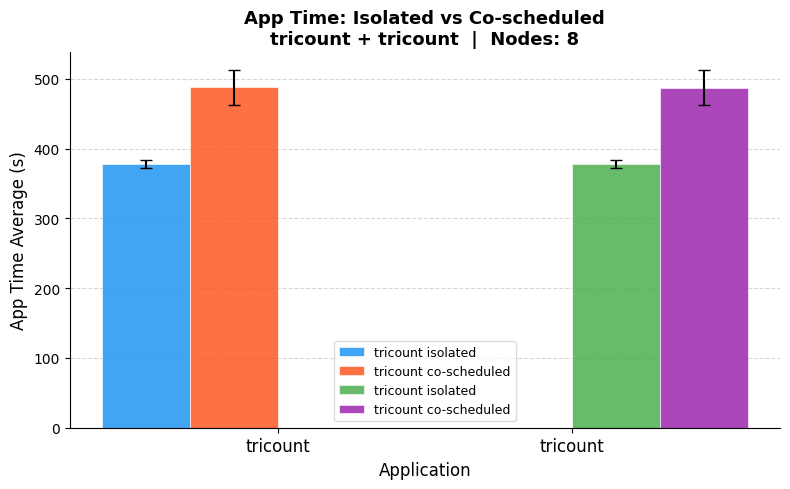

In [7]:
def plot_coscheduled_comparisons(data_isolated_agg, data_coscheduled_agg, metric="app", num_nodes=-1):
    
    if (num_nodes == -1):
        data_coscheduled_agg_filtered = data_coscheduled_agg
        data_isolated_agg_filtered = data_isolated_agg
    else:
        data_coscheduled_agg_filtered = data_coscheduled_agg[data_coscheduled_agg["Num Nodes"] == num_nodes]
        data_isolated_agg_filtered = data_isolated_agg[data_isolated_agg["Num Nodes"] == num_nodes]

    if metric == "app":
        iso_mean_col   = 'App Time Average Mean'
        iso_std_col    = 'App Time Average Std'
        cos_a_mean_col = 'App A Time Average Mean'
        cos_a_std_col  = 'App A Time Average Std'
        cos_b_mean_col = 'App B Time Average Mean'
        cos_b_std_col  = 'App B Time Average Std'
        y_label        = 'App Time Average (s)'
        title_metric   = 'App Time'
    elif metric == "mpi":
        iso_mean_col   = 'MPI Time Average Mean'
        iso_std_col    = 'MPI Time Average Std'
        cos_a_mean_col = 'App A MPI Time Average Mean'
        cos_a_std_col  = 'App A MPI Time Average Std'
        cos_b_mean_col = 'App B MPI Time Average Mean'
        cos_b_std_col  = 'App B MPI Time Average Std'
        y_label        = 'MPI Time Average (s)'
        title_metric   = 'MPI Time'
    else:
        raise ValueError(f"Unknown metric '{metric}'. Choose 'app' or 'mpi'.")

    for _, cosched_row in data_coscheduled_agg_filtered.iterrows():
        app_a = cosched_row['App A']
        app_b = cosched_row['App B']
        num_nodes = cosched_row['Num Nodes']

        iso_a = data_isolated_agg_filtered[
            (data_isolated_agg_filtered['App'] == app_a) &
            (data_isolated_agg_filtered['Num Nodes'] == num_nodes)
        ]
        iso_b = data_isolated_agg_filtered[
            (data_isolated_agg_filtered['App'] == app_b) &
            (data_isolated_agg_filtered['Num Nodes'] == num_nodes)
        ]

        iso_a_mean = iso_a[iso_mean_col].values[0] if not iso_a.empty else 0
        iso_a_std  = iso_a[iso_std_col].values[0]  if not iso_a.empty else 0
        iso_b_mean = iso_b[iso_mean_col].values[0] if not iso_b.empty else 0
        iso_b_std  = iso_b[iso_std_col].values[0]  if not iso_b.empty else 0

        cos_a_mean = cosched_row[cos_a_mean_col]
        cos_a_std  = cosched_row[cos_a_std_col]
        cos_b_mean = cosched_row[cos_b_mean_col]
        cos_b_std  = cosched_row[cos_b_std_col]

        fig, ax = plt.subplots(figsize=(8, 5))

        bar_width = 0.18
        x = np.array([0.0, 0.6])
        offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * bar_width

        bars_data = [
            (x[0] + offsets[0], iso_a_mean, iso_a_std,  '#2196F3', f'{app_a} isolated'),
            (x[0] + offsets[1], cos_a_mean, cos_a_std,  '#FF5722', f'{app_a} co-scheduled'),
            (x[1] + offsets[2], iso_b_mean, iso_b_std,  '#4CAF50', f'{app_b} isolated'),
            (x[1] + offsets[3], cos_b_mean, cos_b_std,  '#9C27B0', f'{app_b} co-scheduled'),
        ]

        for xpos, mean, std, color, label in bars_data:
            ax.bar(xpos, mean, width=bar_width, color=color, label=label,
                   yerr=std, capsize=4, alpha=0.85, edgecolor='white', linewidth=0.5)

        ax.set_xticks(x)
        ax.set_xticklabels([app_a, app_b], fontsize=12)
        ax.set_xlabel('Application', fontsize=12)
        ax.set_ylabel(y_label, fontsize=12)
        ax.set_title(
            f'{title_metric}: Isolated vs Co-scheduled\n'
            f'{app_a} + {app_b}  |  Nodes: {num_nodes}',
            fontsize=13, fontweight='bold'
        )

        ax.legend(fontsize=9, framealpha=0.7)
        ax.yaxis.grid(True, linestyle='--', alpha=0.5)
        ax.set_axisbelow(True)
        ax.spines[['top', 'right']].set_visible(False)

        plt.tight_layout()
        # plt.savefig(f'coscheduled_{app_a}_{app_b}_nodes{num_nodes}_{metric}.png', dpi=150)
        plt.show()
plot_coscheduled_comparisons(data_isolated_agg, data_coscheduled_agg, metric="app", num_nodes=8)

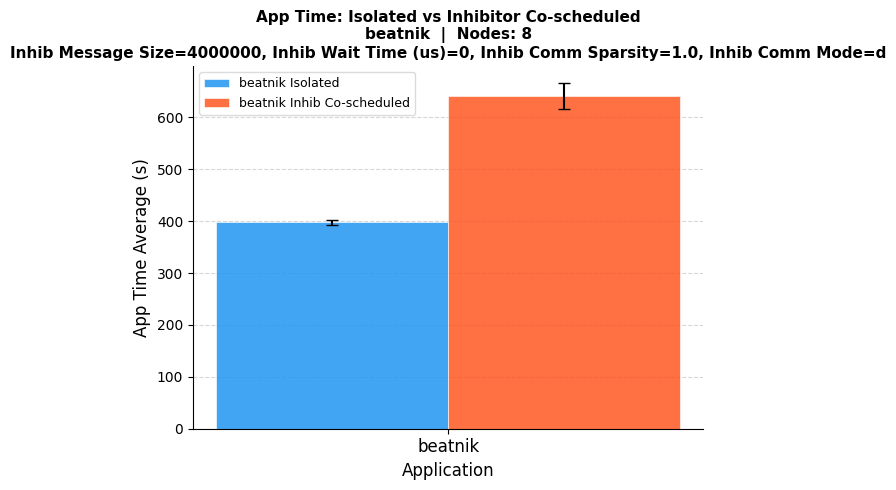

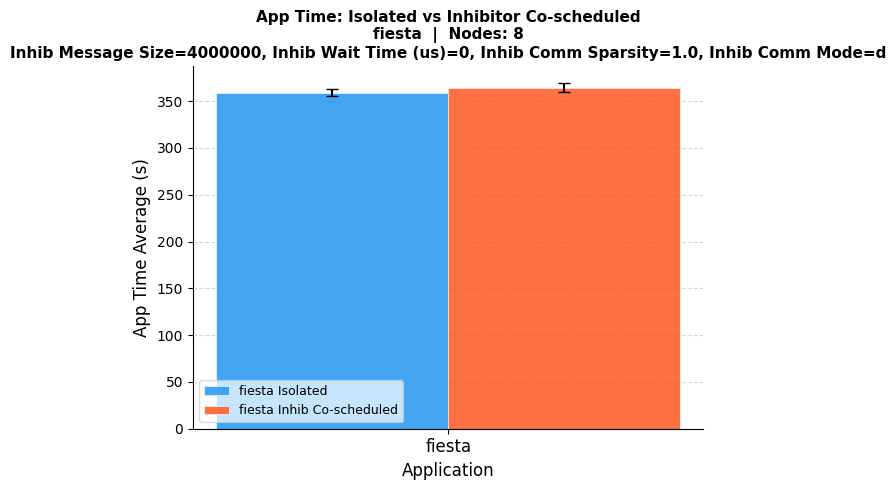

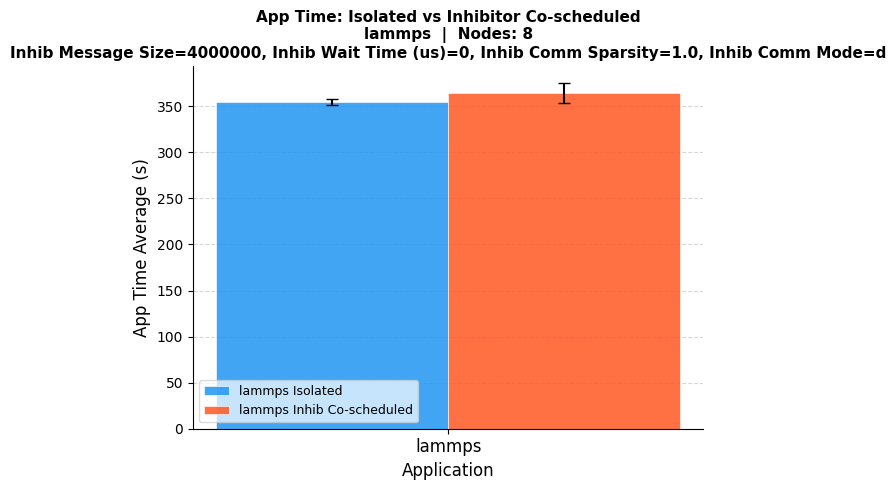

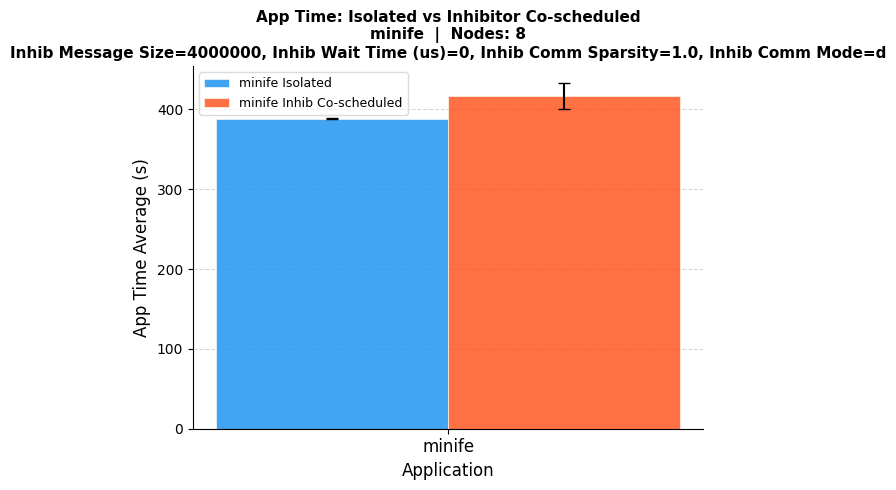

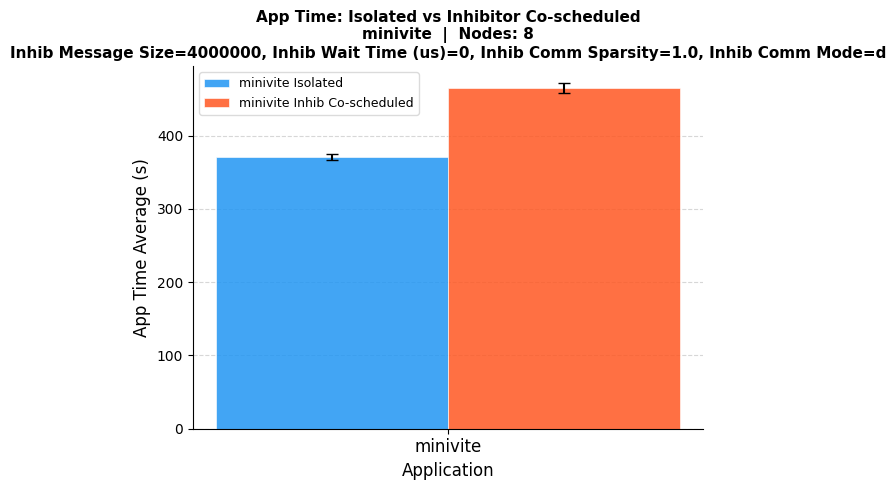

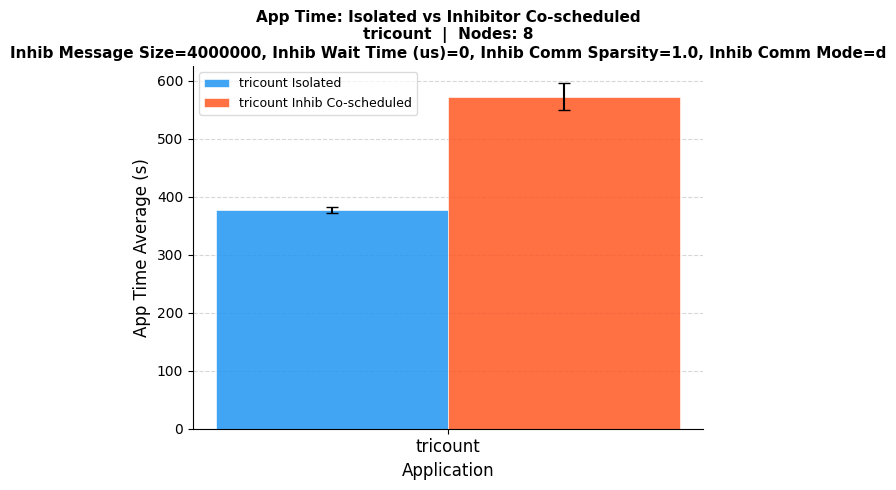

In [8]:
def plot_inhib_coscheduled_comparisons(
    data_isolated_agg,
    data_inhib_coscheduled_agg,
    metric="app",
    inhib_message_size=None,
    inhib_wait_time=None,
    inhib_comm_sparsity=None,
    inhib_comm_mode=None,
):
    if metric == "app":
        iso_mean_col   = 'App Time Average Mean'
        iso_std_col    = 'App Time Average Std'
        inh_mean_col   = 'App Time Average Mean'
        inh_std_col    = 'App Time Average Std'
        y_label        = 'App Time Average (s)'
        title_metric   = 'App Time'
    elif metric == "mpi":
        iso_mean_col   = 'MPI Time Average Mean'
        iso_std_col    = 'MPI Time Average Std'
        inh_mean_col   = 'MPI Time Average Mean'
        inh_std_col    = 'MPI Time Average Std'
        y_label        = 'MPI Time Average (s)'
        title_metric   = 'MPI Time'
    else:
        raise ValueError(f"Unknown metric '{metric}'. Choose 'app' or 'mpi'.")

    # --- Filter inhibitor dataframe ---
    df = data_inhib_coscheduled_agg.copy()
    filter_params = {
        'Inhib Message Size':    inhib_message_size,
        'Inhib Wait Time (us)':  inhib_wait_time,
        'Inhib Comm Sparsity':   inhib_comm_sparsity,
        'Inhib Comm Mode':       inhib_comm_mode,
    }
    for col, val in filter_params.items():
        if val is not None:
            df = df[df[col] == val]

    if df.empty:
        print("No rows match the given inhibitor filters.")
        return

    for _, inh_row in df.iterrows():
        app       = inh_row['App']
        num_nodes = inh_row['Num Nodes']

        # Build a subtitle from whichever filters are active
        active_filters = {k: v for k, v in filter_params.items() if v is not None}
        filter_str = ', '.join(f'{k}={v}' for k, v in active_filters.items()) or 'No filters'

        # Look up isolated stats
        iso = data_isolated_agg[
            (data_isolated_agg['App'] == app) &
            (data_isolated_agg['Num Nodes'] == num_nodes)
        ]
        iso_mean = iso[iso_mean_col].values[0] if not iso.empty else 0
        iso_std  = iso[iso_std_col].values[0]  if not iso.empty else 0

        inh_mean = inh_row[inh_mean_col]
        inh_std  = inh_row[inh_std_col]

        # --- Plot ---
        fig, ax = plt.subplots(figsize=(6, 5))

        bar_width = 0.25
        x = np.array([0.0])
        offsets = np.array([-0.5, 0.5]) * bar_width

        bars_data = [
            (x[0] + offsets[0], iso_mean, iso_std, '#2196F3', f'{app} Isolated'),
            (x[0] + offsets[1], inh_mean, inh_std, '#FF5722', f'{app} Inhib Co-scheduled'),
        ]

        for xpos, mean, std, color, label in bars_data:
            ax.bar(xpos, mean, width=bar_width, color=color, label=label,
                   yerr=std, capsize=4, alpha=0.85, edgecolor='white', linewidth=0.5)

        ax.set_xticks([0.0])
        ax.set_xticklabels([app], fontsize=12)
        ax.set_xlabel('Application', fontsize=12)
        ax.set_ylabel(y_label, fontsize=12)
        ax.set_title(
            f'{title_metric}: Isolated vs Inhibitor Co-scheduled\n'
            f'{app}  |  Nodes: {num_nodes}\n'
            f'{filter_str}',
            fontsize=11, fontweight='bold'
        )

        ax.legend(fontsize=9, framealpha=0.7)
        ax.yaxis.grid(True, linestyle='--', alpha=0.5)
        ax.set_axisbelow(True)
        ax.spines[['top', 'right']].set_visible(False)

        plt.tight_layout()

        safe_filter = '_'.join(str(v) for v in active_filters.values()) or 'nofilter'
        # plt.savefig(f'inhib_{app}_nodes{num_nodes}_{metric}_{safe_filter}.png', dpi=150)
        plt.show()

plot_inhib_coscheduled_comparisons(data_isolated_agg, data_inhib_coscheduled_agg,
                                   metric="app",
                                   inhib_message_size=4000000,
                                   inhib_comm_sparsity=1.0,
                                   inhib_wait_time=0,
                                   inhib_comm_mode="d")

In [9]:
plot_inhib_coscheduled_comparisons(data_isolated_agg, data_inhib_coscheduled_agg,
                                   metric="app",
                                   inhib_message_size=35000,
                                   inhib_comm_sparsity=0.2,
                                   inhib_wait_time=100000,
                                   inhib_comm_mode="d")

No rows match the given inhibitor filters.


In [10]:
# Generate combined, training df

data_isolated_agg = pd.read_csv("../processed_data/data_isolated_agg.csv", index_col=0)
data_coscheduled_agg = pd.read_csv("../processed_data/data_coscheduled_agg.csv", index_col=0)
data_inhib_coscheduled_agg = pd.read_csv("../processed_data/data_inhib_coscheduled_agg.csv", index_col=0)

data_isolated_agg = data_isolated_agg[data_isolated_agg["Num Nodes"] == 8]
data_coscheduled_agg = data_coscheduled_agg[data_coscheduled_agg["Num Nodes"] == 8]
data_inhib_coscheduled_agg = data_inhib_coscheduled_agg[data_inhib_coscheduled_agg["Num Nodes"] == 8]

# --- Step 1: Get all unique (App, Num Nodes) pairs from isolated data ---
isolated_lookup = data_isolated_agg.set_index(['App', 'Num Nodes'])['App Time Average Mean']

# --- Step 2: Get all unique inhib configs (per Num Nodes) ---
inhib_config_cols = ['Inhib Message Size', 'Inhib Wait Time (us)', 'Inhib Comm Sparsity', 'Inhib Comm Mode']
inhib_configs = data_inhib_coscheduled_agg[['Num Nodes'] + inhib_config_cols].drop_duplicates()

# --- Step 3: Get all unique apps per Num Nodes from coscheduled data ---
# All apps that appear in coscheduled pairs
apps_per_nodes = (
    pd.concat([
        data_coscheduled_agg[['App A', 'Num Nodes']].rename(columns={'App A': 'App'}),
        data_coscheduled_agg[['App B', 'Num Nodes']].rename(columns={'App B': 'App'}),
    ])
    .drop_duplicates()
)

# --- Step 4: Get unique (App A, App B, Num Nodes) combos ---
# Group apps by Num Nodes, then generate unique unordered pairs
rows = []

for num_nodes, group in apps_per_nodes.groupby('Num Nodes'):
    apps = group['App'].unique()
    for app_a, app_b in combinations(sorted(apps), 2):

        row = {}
        row['App A'] = app_a
        row['App B'] = app_b
        row['Num Nodes'] = num_nodes

        # --- Isolated times ---
        row['App A Isolated Time'] = isolated_lookup.get((app_a, num_nodes), None)
        row['App B Isolated Time'] = isolated_lookup.get((app_b, num_nodes), None)

        # --- Inhib co-scheduled times for App A and App B ---
        # Filter inhib configs matching this Num Nodes
        node_inhib_configs = inhib_configs[inhib_configs['Num Nodes'] == num_nodes]

        for _, cfg in node_inhib_configs.iterrows():
            cfg_filter = (
                (data_inhib_coscheduled_agg['Num Nodes'] == num_nodes) &
                (data_inhib_coscheduled_agg['Inhib Message Size'] == cfg['Inhib Message Size']) &
                (data_inhib_coscheduled_agg['Inhib Wait Time (us)'] == cfg['Inhib Wait Time (us)']) &
                (data_inhib_coscheduled_agg['Inhib Comm Sparsity'] == cfg['Inhib Comm Sparsity']) &
                (data_inhib_coscheduled_agg['Inhib Comm Mode'] == cfg['Inhib Comm Mode'])
            )

            cfg_label = (
                f"MsgSz={cfg['Inhib Message Size']}_"
                f"Wait={cfg['Inhib Wait Time (us)']}us_"
                f"Sparsity={cfg['Inhib Comm Sparsity']}_"
                f"Mode={cfg['Inhib Comm Mode']}"
            )

            for app, col_prefix in [(app_a, 'App A'), (app_b, 'App B')]:
                app_filter = cfg_filter & (data_inhib_coscheduled_agg['App'] == app)
                match = data_inhib_coscheduled_agg[app_filter]
                col_name = f"{col_prefix} Co-Scheduled Time with Inhib [{cfg_label}]"
                row[col_name] = match['App Time Average Mean'].values[0] if len(match) > 0 else None

        # --- Co-scheduled time with each other (from data_coscheduled_agg) ---
        cosched_filter = (
            (data_coscheduled_agg['Num Nodes'] == num_nodes) &
            (data_coscheduled_agg['App A'] == app_a) &
            (data_coscheduled_agg['App B'] == app_b)
        )
        cosched_match = data_coscheduled_agg[cosched_filter]

        # Also check reversed order
        cosched_filter_rev = (
            (data_coscheduled_agg['Num Nodes'] == num_nodes) &
            (data_coscheduled_agg['App A'] == app_b) &
            (data_coscheduled_agg['App B'] == app_a)
        )
        cosched_match_rev = data_coscheduled_agg[cosched_filter_rev]

        if len(cosched_match) > 0:
            row['App A Co-Scheduled Time with App B'] = cosched_match['App A Time Average Mean'].values[0]
            row['App B Co-Scheduled Time with App A'] = cosched_match['App B Time Average Mean'].values[0]
        elif len(cosched_match_rev) > 0:
            # A and B are swapped in the source df, so flip the columns
            row['App A Co-Scheduled Time with App B'] = cosched_match_rev['App B Time Average Mean'].values[0]
            row['App B Co-Scheduled Time with App A'] = cosched_match_rev['App A Time Average Mean'].values[0]
        else:
            row['App A Co-Scheduled Time with App B'] = None
            row['App B Co-Scheduled Time with App A'] = None

        rows.append(row)

data_combined_training_df = pd.DataFrame(rows)
data_combined_training_df 

,App A,App B,Num Nodes,App A Isolated Time,App B Isolated Time,App A Co-Scheduled Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.1_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.1_Mode=d],App A Co-Scheduled Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.3_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.3_Mode=d],App A Co-Scheduled Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.5_Mode=d],...,App A Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.3_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.3_Mode=d],App A Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.5_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.5_Mode=d],App A Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.7_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.7_Mode=d],App A Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=1.0_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=1.0_Mode=d],App A Co-Scheduled Time with App B,App B Co-Scheduled Time with App A
0,amg,beatnik,8,342.500000,397.734375,NaN,425.018415,NaN,411.276228,NaN,...,NaN,499.573103,NaN,477.118304,NaN,492.273996,NaN,634.975446,345.750000,407.433594
1,amg,fiesta,8,342.500000,359.091518,NaN,367.840960,NaN,352.824219,NaN,...,NaN,353.354911,NaN,356.449219,NaN,355.733259,NaN,368.329241,342.000000,356.289062
2,amg,kripke,8,342.500000,354.500000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,343.000000,354.750000
3,amg,laghos,8,342.500000,331.237723,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,343.750000,359.750000
4,amg,lammps,8,342.500000,354.750000,NaN,361.500000,NaN,351.750000,NaN,...,NaN,362.250000,NaN,363.500000,NaN,363.750000,NaN,364.250000,342.750000,353.750000
5,amg,minife,8,342.500000,388.250000,NaN,398.500000,NaN,386.500000,NaN,...,NaN,401.250000,NaN,401.750000,NaN,404.500000,NaN,409.250000,341.039621,384.250000
6,amg,minivite,8,342.500000,371.250000,NaN,388.250000,NaN,380.000000,NaN,...,NaN,413.250000,NaN,408.500000,NaN,420.500000,NaN,446.500000,342.500000,371.750000
7,amg,quicksilver,8,342.500000,295.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,341.750000,296.376674
8,amg,tricount,8,342.500000,378.000000,NaN,436.500000,NaN,405.000000,NaN,...,NaN,565.750000,NaN,616.750000,NaN,584.000000,NaN,619.000000,347.000000,389.000000
9,beatnik,fiesta,8,397.734375,359.091518,425.018415,367.840960,411.276228,352.824219,408.000000,...,499.573103,353.354911,477.118304,356.449219,492.273996,355.733259,634.975446,368.329241,407.750000,353.320312


In [ ]:
# Write processed combined df to csv
data_combined_training_df.to_csv("../processed_data/data_combined_training.csv")

In [14]:
# Old isolated data, spread across both sockets

olddata_isolated = parser.parse_isolated("../sample_data/old_data/sample_data/experiments_coscheduling_isolated/20260521_194041/data")
olddata_isolated_agg = olddata_isolated.groupby(['App', 'Num Nodes']).agg({
    'App Time Average': ['mean', 'median', 'std'],
    'MPI Time Average': ['mean', 'median', 'std'],
    'Total Messages Sent': ['mean', 'median', 'std']
}).reset_index()

# Flatten column names
olddata_isolated_agg.columns = ['App', 'Num Nodes', 
                             'App Time Average Mean', 'App Time Average Median', 'App Time Average Std',
                             'MPI Time Average Mean', 'MPI Time Average Median', 'MPI Time Average Std',
                             'Total Messages Sent Mean', 'Total Messages Sent Median', 'Total Messages Sent Std']

olddata_isolated_agg

,App,Num Nodes,App Time Average Mean,App Time Average Median,App Time Average Std,MPI Time Average Mean,MPI Time Average Median,MPI Time Average Std,Total Messages Sent Mean,Total Messages Sent Median,Total Messages Sent Std
0,beatnik,1,293.924107,294.000000,2.842985,66.274107,66.054464,1.256402,375894.0,375894.0,0.00000
1,fiesta,1,167.482143,167.464286,0.557494,14.307991,14.479911,0.661255,67200.0,67200.0,0.00000
2,lammps,1,215.000000,215.000000,0.000000,7.609420,7.614018,0.307746,44688.0,44688.0,0.00000
3,minife,1,207.750000,208.000000,2.629956,7.266964,7.387500,2.888209,637048.0,637048.0,0.00000
4,minivite,1,285.250000,260.000000,52.576135,45.151920,19.516339,53.670820,749746.5,749754.0,3058.84537
5,tricount,1,237.250000,237.000000,1.258306,56.894643,56.918750,0.952683,243320.0,243320.0,0.00000


In [16]:
data_isolated_agg.columns

Index(['App', 'Num Nodes', 'App Time Average Mean', 'App Time Average Median',
       'App Time Average Std', 'MPI Time Average Mean',
       'MPI Time Average Median', 'MPI Time Average Std',
       'Total Messages Sent Mean', 'Total Messages Sent Median',
       'Total Messages Sent Std'],
      dtype='object')

In [27]:
data_isolated_old_vs_new = []
columns = ['App', 'Num Nodes', 'Old App Time Mean', 'Old MPI Time Mean', 'App Time Average Mean Diff',
            'MPI Time Average Mean Diff', 'Total Messages Sent Mean']
for i in data_isolated_agg.iloc:
    filtered_olddata = olddata_isolated_agg[olddata_isolated_agg["App"] == i["App"]]
    data_isolated_old_vs_new.append([i["App"], i["Num Nodes"], filtered_olddata.iloc[0]['App Time Average Mean'],
                                     filtered_olddata.iloc[0]['MPI Time Average Mean'],
                                     i["App Time Average Mean"] - filtered_olddata.iloc[0]["App Time Average Mean"],
                                     i["MPI Time Average Mean"] - filtered_olddata.iloc[0]["MPI Time Average Mean"],
                                     i["Total Messages Sent Mean"]])

data_isolated_old_vs_new_df = pd.DataFrame(data_isolated_old_vs_new)
data_isolated_old_vs_new_df.columns = columns
data_isolated_old_vs_new_df = data_isolated_old_vs_new_df.sort_values("Old MPI Time Mean")
data_isolated_old_vs_new_df 

,App,Num Nodes,Old App Time Mean,Old MPI Time Mean,App Time Average Mean Diff,MPI Time Average Mean Diff,Total Messages Sent Mean
3,minife,1,207.750000,7.266964,176.000000,2.433527,637048.0
2,lammps,1,215.000000,7.609420,50.750000,-4.337411,44688.0
1,fiesta,1,167.482143,14.307991,131.200893,22.958170,67200.0
4,minivite,1,285.250000,45.151920,156.000000,-17.330536,747720.0
5,tricount,1,237.250000,56.894643,43.250000,-7.372321,243320.0
0,beatnik,1,293.924107,66.274107,76.223214,18.495089,375894.0


In [23]:
olddata_isolated_agg

,App,Num Nodes,App Time Average Mean,App Time Average Median,App Time Average Std,MPI Time Average Mean,MPI Time Average Median,MPI Time Average Std,Total Messages Sent Mean,Total Messages Sent Median,Total Messages Sent Std
0,beatnik,1,293.924107,294.000000,2.842985,66.274107,66.054464,1.256402,375894.0,375894.0,0.00000
1,fiesta,1,167.482143,167.464286,0.557494,14.307991,14.479911,0.661255,67200.0,67200.0,0.00000
2,lammps,1,215.000000,215.000000,0.000000,7.609420,7.614018,0.307746,44688.0,44688.0,0.00000
3,minife,1,207.750000,208.000000,2.629956,7.266964,7.387500,2.888209,637048.0,637048.0,0.00000
4,minivite,1,285.250000,260.000000,52.576135,45.151920,19.516339,53.670820,749746.5,749754.0,3058.84537
5,tricount,1,237.250000,237.000000,1.258306,56.894643,56.918750,0.952683,243320.0,243320.0,0.00000
